<a href="https://colab.research.google.com/github/EmanueleDeCandia/Logistica-Vending-Machine/blob/main/Monte_Carlo_OCS_revisionato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo OCS: Analisi di Rischio e Redditività


## Utilizzo
È possibile aggiungere tutti gli addetti necessari. La regione viene calcolata sommando, in ogni iterazione Monte Carlo, i risultati dei singoli portafogli.

Questo permette di individuare:
* Addetti con portafogli strutturalmente meno redditizi
* Differenze di densità logistica
* Rischio di sovraccarico
* Costo per cliente
* Valore e margine prodotto da ciascun addetto
* Probabilità di perdita del singolo portafoglio
* Rischio complessivo regionale

La scelta delle variabili riflette componenti rilevanti nell’OCS: densità dei percorsi, affidabilità delle macchine, inflazione e livelli di servizio.

---

## Variabili Stocastiche Inserite

### 1. Domanda e Profittabilità
* Variazione del numero di clienti attivi
* Variazione del valore annuo medio del cliente
* Ordini in meno, sconti, insoluti e rettifiche
* Perdita di ricavo durante il fermo macchina

### 2. Logistica
* Visite extra (ordini incompleti o urgenti)
* Clienti last-minute e sforamento chilometri
* Durata del servizio e inflazione costi chilometrici

### 3. Personale
* Giorni di assenza e costi di sostituzione
* Straordinari e saturazione oraria

### 4. Macchine OCS e Prodotti
* Giorni di fermo, guasti e costi di intervento
* Incidenza costo prodotti e relativa inflazione

---

## Controllo dell’Incertezza

Ogni variabile è configurata con una distribuzione gaussiana troncata:

```json
"visite_extra_ordini_incompleti_pct": {
    "mean": 0.055,
    "sd": 0.030,
    "min": 0.00,
    "max": 0.20
}
```

È possibile scalare l'incertezza globale tramite il parametro `UNCERTAINTY_MULTIPLIER` (es. `0.50` per dimezzarla, `2.00` per raddoppiarla).

### Variabili Opzionali
Alcune variabili (come il *churn* o i tempi di parcheggio) sono predisposte nel codice ma disattivate con `#`. Per attivarle, è necessario rimuovere il commento sia nella configurazione `SHOCKS` che nella funzione `simula_addetto()`.

---

## Risultati della Prova Tecnica (Esempio)

Con 10.000 simulazioni e parametri dimostrativi:

| Indicatore | Risultato |
| :--- | :--- |
| **Margine medio regionale** | € 13.572 |
| **Margine P5 (Rischio)** | -€ 28.927 |
| **Margine mediano** | € 13.310 |
| **Margine P95 (Opportunità)** | € 56.821 |
| **Probabilità di perdita** | 29,98% |
| **ROI medio** | 2,47% |
| **Probabilità di sovraccarico** | 85,29% |

> **Nota:** Questi risultati sono puramente esemplificativi e dipendono dai parametri di input inseriti.

L'output Excel generato contiene i fogli di dettaglio per input, sintesi area/addetti, analisi di sensibilità e simulazioni complete.


### Analisi Tecnica del Modello di Simulazione

Il codice implementa un motore di simulazione **Monte Carlo** personalizzato per il settore OCS. Ecco i pilastri logici del primo blocco:

#### 1. Configurazione e Portafogli
Il modello definisce parametri operativi standard (velocità media, ore lavorative, giorni annui) e accetta una lista di `PORTAFOGLI_ADDETTI`. Ogni portafoglio rappresenta un'entità economica separata con i propri clienti base, chilometri percorsi e costi fissi.

#### 2. Motore degli Shock (Incertezza)
Il cuore della simulazione risiede nel dizionario `SHOCKS`. Ogni variabile (es. inflazione, guasti, variazioni di volume) è definita come una distribuzione **Gaussiana Troncata**:
* **Media (`mean`)**: Il valore atteso.
* **Deviazione Standard (`sd`)**: L'ampiezza dell'incertezza.
* **Limiti (`min`/`max`)**: Impediscono valori irrealistici (es. costi negativi o inflazione infinita).
* **`UNCERTAINTY_MULTIPLIER`**: Un parametro globale per testare scenari di stress (es. raddoppiando l'incertezza).

#### 3. Logica di Simulazione (`simula_addetto`)
Per ogni iterazione (default 5.000), il codice:
1. **Estrae valori casuali** per tutti i driver di rischio.
2. **Calcola l'impatto a cascata**: Ad esempio, un aumento di clienti impatta i chilometri, che impattano il tempo di guida, che può generare straordinari (costo del personale).
3. **Determina i Margini**: Sottrae dai ricavi netti (corretti per fermi macchina e insoluti) i costi operativi (logistica, prodotto, manutenzione, personale).

#### 4. Aggregazione Regionale
La funzione `simula_regione` coordina l'esecuzione. Gli shock "macro" (come l'inflazione dei prodotti) sono mantenuti coerenti per tutti gli addetti nella stessa iterazione, simulando un mercato reale dove certi rischi colpiscono l'intera regione simultaneamente.


In [ ]:
import os
from pathlib import Path

# Configurazione ambiente e cartelle (compatibile sia con Google Colab che con ambiente locale)
BASE_DIR = Path('/mnt/data') if os.path.exists('/mnt/data') or os.name != 'nt' else Path('./data')
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "output_monte_carlo_ocs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Cartella base di lavoro: {BASE_DIR.resolve()}")
print(f"✅ Cartella output per risultati e grafici: {OUTPUT_DIR.resolve()}")


✅ Cartella base di lavoro: /mnt/data
✅ Cartella output per risultati e grafici: /mnt/data/output_monte_carlo_ocs


In [ ]:
"""
Monte Carlo OCS: rischio logistico e redditività
================================================
BLOCCO 1: DEFINIZIONE PARAMETRI BASE, VARIABILI ALEATORIE E FORMULE DI SIMULAZIONE.
Integrazione del Costo Operativo e Logistico per Visita Reale (€20-€30/visita) ed Erosione Margini.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- PARAMETRI GENERALI DELLA SIMULAZIONE ---
SEED = 42
N_SIMULATIONS = 1_000
UNCERTAINTY_MULTIPLIER = 1.0

# --- OPERATIVITÀ BASE ---
GIORNI_LAVORATIVI_MESE = 22
MESI_ANNO = 12
GIORNI_LAVORATIVI_ANNO = GIORNI_LAVORATIVI_MESE * MESI_ANNO
ORE_LAVORATIVE_GIORNO = 8.0
VELOCITA_MEDIA_KMH = 30.0

# Configurazione ambiente e cartelle
BASE_DIR = Path('/mnt/data') if os.path.exists('/mnt/data') or os.name != 'nt' else Path('./data')
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "output_monte_carlo_ocs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- PORTAFOGLI REALI DEGLI ADDETTI ---
PORTAFOGLI_ADDETTI = [
    {
        "area": "Marche",
        "addetto": "Addetto_01",
        "clienti_base": 133,
        "km_annui_base": 40_000,
        "valore_annuo_cliente_base": 1000,
        "frequenza_mensile_base": 1.0,
        "costo_lavoro_annuo_base": 36_000,
        "costo_km_base": 0.25,
        "costo_manutenzione_macchina_base": 50,
        "macchine_per_cliente": 1.0,
    },
    {
        "area": "Marche",
        "addetto": "Addetto_02",
        "clienti_base": 133,
        "km_annui_base": 48_000,
        "valore_annuo_cliente_base": 1000,
        "frequenza_mensile_base": 1.0,
        "costo_lavoro_annuo_base": 36_000,
        "costo_km_base": 0.25,
        "costo_manutenzione_macchina_base": 50,
        "macchine_per_cliente": 1.0,
    },
    {
        "area": "Marche",
        "addetto": "Addetto_03",
        "clienti_base": 133,
        "km_annui_base": 56_000,
        "valore_annuo_cliente_base": 1000,
        "frequenza_mensile_base": 1.0,
        "costo_lavoro_annuo_base": 36_000,
        "costo_km_base": 0.25,
        "costo_manutenzione_macchina_base": 50,
        "macchine_per_cliente": 1.0,
    },
]

# --- DISTRIBUZIONI DI INCERTEZZA (SHOCKS STOCASTICI) ---
SHOCKS = {
    # DOMANDA E CLIENTI
    "variazione_clienti_pct": dict(mean=0.00, sd=0.035, min=-0.12, max=0.12),
    "variazione_valore_cliente_pct": dict(mean=0.00, sd=0.08, min=-0.25, max=0.30),
    "ordini_in_meno_pct": dict(mean=0.025, sd=0.018, min=0.00, max=0.12),
    "rettifiche_ricavi_pct": dict(mean=0.015, sd=0.010, min=0.00, max=0.07),

    # VISITE E PERCORSI
    "visite_extra_ordini_incompleti_pct": dict(mean=0.055, sd=0.030, min=0.00, max=0.20),
    "visite_urgenti_pct": dict(mean=0.10, sd=0.018, min=0.08, max=0.12),
    "sforamento_km_percorso_pct": dict(mean=0.045, sd=0.035, min=-0.04, max=0.22),
    "km_extra_per_visita": dict(mean=30.0, sd=6.0, min=20.0, max=60.0),
    "minuti_servizio_per_visita": dict(mean=10.0, sd=5.0, min=5.0, max=20.0),

    # PERSONALE
    "giorni_assenza_addetto": dict(mean=5.0, sd=4.0, min=0.0, max=30.0),
    "costo_sostituzione_giorno": dict(mean=185.0, sd=30.0, min=100.0, max=300.0),
    "costo_straordinario_ora": dict(mean=28.0, sd=4.0, min=18.0, max=45.0),

    # MACCHINE OCS
    "giorni_fermo_macchina_per_cliente": dict(mean=2.0, sd=1.2, min=0.0, max=8.0),
    "quota_ricavo_persa_durante_fermo": dict(mean=0.65, sd=0.12, min=0.20, max=1.00),
    "guasti_straordinari_per_100_macchine": dict(mean=5.0, sd=3.0, min=1.0, max=10.0),
    "costo_medio_intervento_guasto": dict(mean=145.0, sd=40.0, min=50.0, max=350.0),

    # PRODOTTI E LOGISTICA
    "costo_prodotti_pct_ricavi": dict(mean=0.45, sd=0.05, min=0.40, max=0.50),
    "inflazione_prodotti_pct": dict(mean=0.035, sd=0.025, min=-0.03, max=0.15),
    "inflazione_costo_km_pct": dict(mean=0.035, sd=0.030, min=-0.06, max=0.18),
    "variazione_manutenzione_pct": dict(mean=0.00, sd=0.12, min=-0.20, max=0.40),
}


def gauss(rng, cfg, n):
    values = rng.normal(cfg["mean"], cfg["sd"] * UNCERTAINTY_MULTIPLIER, n)
    return np.clip(values, cfg["min"], cfg["max"])


def draw_all(rng, n):
    return {name: gauss(rng, cfg, n) for name, cfg in SHOCKS.items()}


def div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.divide(a, b, out=np.zeros_like(a), where=b != 0)


def simula_addetto(cfg, macro, rng, n):
    s = draw_all(rng, n)
    s["inflazione_prodotti_pct"] = macro["inflazione_prodotti_pct"]
    s["inflazione_costo_km_pct"] = macro["inflazione_costo_km_pct"]

    clienti = np.maximum(
        np.rint(cfg["clienti_base"] * (1 + s["variazione_clienti_pct"])),
        1,
    )

    macchine = clienti * cfg["macchine_per_cliente"]
    valore_cliente = cfg["valore_annuo_cliente_base"] * (
        1 + s["variazione_valore_cliente_pct"]
    )
    ricavi_lordi = clienti * valore_cliente
    perdita_ordini = ricavi_lordi * s["ordini_in_meno_pct"]
    perdita_fermo = (
        ricavi_lordi
        * s["giorni_fermo_macchina_per_cliente"]
        / 365
        * s["quota_ricavo_persa_durante_fermo"]
    )
    rettifiche = ricavi_lordi * s["rettifiche_ricavi_pct"]
    ricavi_netti = np.maximum(
        ricavi_lordi - perdita_ordini - perdita_fermo - rettifiche,
        0,
    )

    visite_programmate = (
        clienti * cfg["frequenza_mensile_base"] * MESI_ANNO
    )
    visite_extra = visite_programmate * s["visite_extra_ordini_incompleti_pct"]
    visite_urgenti = visite_programmate * s["visite_urgenti_pct"]
    visite_totali = visite_programmate + visite_extra + visite_urgenti

    km_ordinari_base = cfg["km_annui_base"] * (clienti / cfg["clienti_base"])
    km_sforamento = km_ordinari_base * np.maximum(s["sforamento_km_percorso_pct"], 0)
    km_extra_visite = (visite_extra + visite_urgenti) * s["km_extra_per_visita"]
    km_totali = np.maximum(km_ordinari_base + km_sforamento + km_extra_visite, 0)

    minuti_visita = s["minuti_servizio_per_visita"]

    ore_servizio = visite_totali * minuti_visita / 60
    ore_guida = km_totali / VELOCITA_MEDIA_KMH
    ore_richieste = ore_servizio + ore_guida

    giorni_disponibili = np.maximum(
        GIORNI_LAVORATIVI_ANNO - s["giorni_assenza_addetto"],
        1,
    )
    ore_disponibili = giorni_disponibili * ORE_LAVORATIVE_GIORNO
    straordinario = np.maximum(ore_richieste - ore_disponibili, 0)
    saturazione = div(ore_richieste, ore_disponibili)

    costo_km = cfg["costo_km_base"] * (1 + s["inflazione_costo_km_pct"])
    costo_logistica = km_totali * costo_km

    costo_prodotti_ratio = np.clip(
        s["costo_prodotti_pct_ricavi"] * (1 + s["inflazione_prodotti_pct"]),
        0,
        0.90,
    )
    costo_prodotti = ricavi_netti * costo_prodotti_ratio

    costo_personale = (
        cfg["costo_lavoro_annuo_base"]
        + s["giorni_assenza_addetto"] * s["costo_sostituzione_giorno"]
        + straordinario * s["costo_straordinario_ora"]
    )

    manutenzione = (
        macchine
        * cfg["costo_manutenzione_macchina_base"]
        * (1 + s["variazione_manutenzione_pct"])
    )
    numero_guasti = (
        macchine * s["guasti_straordinari_per_100_macchine"] / 100
    )
    costo_guasti = numero_guasti * s["costo_medio_intervento_guasto"]

    costi_totali = (
        costo_prodotti
        + costo_logistica
        + costo_personale
        + manutenzione
        + costo_guasti
    )
    margine = ricavi_netti - costi_totali
    roi = div(margine, costi_totali) * 100

    # --- COSTO OPERATIVO E LOGISTICO PER VISITA (€20 - €30 / VISITA) ---
    # Esclude il costo delle materie prime (caffè/prodotti venduti) e calcola il puro costo di erogazione servizio e logistica
    costi_servizio_logistica = costo_logistica + costo_personale + manutenzione + costo_guasti
    costo_per_visita = div(costi_servizio_logistica, visite_totali)

    # 1. Costo reale delle visite anomale (Extra + Urgenti) basato sul costo medio per visita (€25 - €30)
    costo_visite_anomale = (visite_extra + visite_urgenti) * costo_per_visita

    # 2. Costo reale dello sforamento percorsi (Km extra deviazione + tempo guida extra addetto)
    costo_ora_guida = div(costo_personale, np.maximum(ore_disponibili, 1))
    costo_sforamento_percorsi = (km_sforamento * costo_km) + ((km_sforamento / VELOCITA_MEDIA_KMH) * costo_ora_guida)

    # 3. Erosione Totale Margine da Logistica Extra
    erosione_totale_logistica_extra = costo_visite_anomale + costo_sforamento_percorsi

    return pd.DataFrame({
        "simulazione": np.arange(1, n + 1),
        "area": cfg["area"],
        "addetto": cfg["addetto"],

        "shock_variazione_clienti_pct": s["variazione_clienti_pct"],
        "shock_variazione_valore_cliente_pct": s["variazione_valore_cliente_pct"],
        "shock_ordini_in_meno_pct": s["ordini_in_meno_pct"],
        "shock_visite_extra_pct": s["visite_extra_ordini_incompleti_pct"],
        "shock_visite_urgenti_pct": s["visite_urgenti_pct"],
        "shock_sforamento_km_pct": s["sforamento_km_percorso_pct"],
        "shock_giorni_assenza": s["giorni_assenza_addetto"],
        "shock_giorni_fermo_macchina": s["giorni_fermo_macchina_per_cliente"],
        "shock_inflazione_prodotti_pct": s["inflazione_prodotti_pct"],
        "shock_inflazione_costo_km_pct": s["inflazione_costo_km_pct"],
        "shock_costo_prodotti_pct": s["costo_prodotti_pct_ricavi"],

        "clienti_attivi": clienti,
        "macchine_attive": macchine,
        "visite_programmate_anno": visite_programmate,
        "visite_extra_anno": visite_extra,
        "visite_urgenti_anno": visite_urgenti,
        "visite_totali_anno": visite_totali,
        "visite_mese": visite_totali / MESI_ANNO,
        "visite_giorno": visite_totali / GIORNI_LAVORATIVI_ANNO,
        "km_totali": km_totali,
        "km_per_visita": div(km_totali, visite_totali),
        "ore_richieste": ore_richieste,
        "ore_disponibili": ore_disponibili,
        "ore_straordinario": straordinario,
        "saturazione_operativa": saturazione,
        "sovraccarico_operativo": saturazione > 1,

        "ricavi_lordi": ricavi_lordi,
        "perdita_ordini": perdita_ordini,
        "perdita_ricavi_fermo": perdita_fermo,
        "rettifiche_ricavi": rettifiche,
        "ricavi_netti": ricavi_netti,
        "costo_prodotti": costo_prodotti,
        "costo_logistica": costo_logistica,
        "costo_sforamento_percorsi": costo_sforamento_percorsi,
        "costo_visite_anomale": costo_visite_anomale,
        "erosione_totale_logistica_extra": erosione_totale_logistica_extra,
        "costo_personale": costo_personale,
        "costo_manutenzione_preventiva": manutenzione,
        "costo_guasti": costo_guasti,
        "costi_operativi_totali": costi_totali,
        "margine_netto_operativo": margine,
        "roi_operativo_pct": roi,
        "valore_per_addetto": ricavi_netti,
        "ricavo_per_cliente": div(ricavi_netti, clienti),
        "costo_per_cliente": div(costi_totali, clienti),
        "margine_per_cliente": div(margine, clienti),
        "costo_per_visita": costo_per_visita,
        "margine_per_visita": div(margine, visite_totali),
    })


def simula_regione(portafogli, n=N_SIMULATIONS, seed=SEED):
    rng = np.random.default_rng(seed)
    macro = {
        "inflazione_prodotti_pct": gauss(
            rng, SHOCKS["inflazione_prodotti_pct"], n
        ),
        "inflazione_costo_km_pct": gauss(
            rng, SHOCKS["inflazione_costo_km_pct"], n
        ),
    }

    dettaglio = pd.concat(
        [simula_addetto(p, macro, rng, n) for p in portafogli],
        ignore_index=True,
    )

    sum_cols = [
        "clienti_attivi", "macchine_attive", "visite_programmate_anno",
        "visite_extra_anno", "visite_urgenti_anno", "visite_totali_anno",
        "km_totali", "ore_richieste", "ore_disponibili",
        "ore_straordinario", "ricavi_lordi", "perdita_ordini",
        "perdita_ricavi_fermo", "rettifiche_ricavi", "ricavi_netti",
        "costo_prodotti", "costo_logistica", "costo_sforamento_percorsi",
        "costo_visite_anomale", "erosione_totale_logistica_extra",
        "costo_personale", "costo_manutenzione_preventiva", "costo_guasti",
        "costi_operativi_totali", "margine_netto_operativo",
    ]
    area = (
        dettaglio.groupby(["area", "simulazione"], as_index=False)[sum_cols]
        .sum()
    )
    n_addetti = len(portafogli)
    area["numero_addetti"] = n_addetti
    area["clienti_per_addetto"] = area["clienti_attivi"] / n_addetti
    area["valore_per_addetto"] = area["ricavi_netti"] / n_addetti
    area["visite_giorno_per_addetto"] = (
        area["visite_totali_anno"] / GIORNI_LAVORATIVI_ANNO / n_addetti
    )
    area["km_per_addetto"] = area["km_totali"] / n_addetti
    area["km_per_cliente"] = div(area["km_totali"], area["clienti_attivi"])
    area["km_per_visita"] = div(area["km_totali"], area["visite_totali_anno"])
    area["ricavo_per_cliente"] = div(area["ricavi_netti"], area["clienti_attivi"])
    area["costo_per_cliente"] = div(
        area["costi_operativi_totali"], area["clienti_attivi"]
    )
    area["margine_per_cliente"] = div(
        area["margine_netto_operativo"], area["clienti_attivi"]
    )
    area["roi_operativo_pct"] = div(
        area["margine_netto_operativo"], area["costi_operativi_totali"]
    ) * 100
    area["saturazione_operativa"] = div(
        area["ore_richieste"], area["ore_disponibili"]
    )
    area["sovraccarico_operativo"] = area["saturazione_operativa"] > 1
    area["costo_per_visita"] = div(area["costo_logistica"] + area["costo_personale"] + area["costo_manutenzione_preventiva"] + area["costo_guasti"], area["visite_totali_anno"])

    drivers = [
        "shock_variazione_clienti_pct",
        "shock_variazione_valore_cliente_pct",
        "shock_ordini_in_meno_pct",
        "shock_visite_extra_pct",
        "shock_visite_urgenti_pct",
        "shock_sforamento_km_pct",
        "shock_giorni_assenza",
        "shock_giorni_fermo_macchina",
        "shock_inflazione_prodotti_pct",
        "shock_inflazione_costo_km_pct",
        "shock_costo_prodotti_pct",
    ]
    avg_drivers = (
        dettaglio.groupby(["area", "simulazione"], as_index=False)[drivers]
        .mean()
    )
    area = area.merge(avg_drivers, on=["area", "simulazione"])
    return dettaglio, area


def summary_table(df, group, indicators):
    rows = []
    for name, data in df.groupby(group):
        for col in indicators:
            x = data[col].dropna()
            rows.append({
                group: name,
                "indicatore": col,
                "P5": x.quantile(0.05),
                "media": x.mean(),
                "mediana_P50": x.median(),
                "P95": x.quantile(0.95),
                "deviazione_standard": x.std(),
                "probabilita_negativo": (x < 0).mean(),
            })
    return pd.DataFrame(rows)


def addetti_summary(df):
    rows = []
    for name, x in df.groupby("addetto"):
        rows.append({
            "addetto": name,
            "clienti_media": x["clienti_attivi"].mean(),
            "valore_per_addetto_media": x["ricavi_netti"].mean(),
            "margine_medio": x["margine_netto_operativo"].mean(),
            "margine_P5": x["margine_netto_operativo"].quantile(0.05),
            "margine_P50": x["margine_netto_operativo"].median(),
            "margine_P95": x["margine_netto_operativo"].quantile(0.95),
            "probabilita_perdita": (x["margine_netto_operativo"] < 0).mean(),
            "roi_medio_pct": x["roi_operativo_pct"].mean(),
            "km_medi": x["km_totali"].mean(),
            "visite_giorno_medie": x["visite_giorno"].mean(),
            "costo_visita_medio": x["costo_per_visita"].mean(),
            "saturazione_media": x["saturazione_operativa"].mean(),
            "probabilita_sovraccarico": x["sovraccarico_operativo"].mean(),
            "costo_cliente_medio": x["costo_per_cliente"].mean(),
            "margine_cliente_medio": x["margine_per_cliente"].mean(),
        })
    return pd.DataFrame(rows)


def sensitivity(area, target="margine_netto_operativo"):
    drivers = [
        "shock_variazione_clienti_pct",
        "shock_variazione_valore_cliente_pct",
        "shock_ordini_in_meno_pct",
        "shock_visite_extra_pct",
        "shock_visite_urgenti_pct",
        "shock_sforamento_km_pct",
        "shock_giorni_assenza",
        "shock_giorni_fermo_macchina",
        "shock_inflazione_prodotti_pct",
        "shock_inflazione_costo_km_pct",
        "shock_costo_prodotti_pct",
    ]
    s = (
        area[drivers + [target]].corr(method="spearman")[target]
        .drop(target)
        .sort_values(key=np.abs, ascending=False)
    )
    return s.to_frame(name="correlazione_spearman").reset_index().rename(columns={"index": "variabile"})


def save_charts(area, detail, sens, out):
    paths = []

    x = area["margine_netto_operativo"]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(x, bins=35, alpha=0.75, edgecolor="black")
    ax.axvline(x.mean(), linestyle="--", color='red', label=f"Media: €{x.mean():,.0f}")
    ax.axvline(x.quantile(.05), linestyle=":", color='orange', label=f"P5: €{x.quantile(.05):,.0f}")
    ax.set(title="Distribuzione Monte Carlo del Margine Netto OCS",
           xlabel="Margine netto operativo annuo (€)",
           ylabel="Numero di simulazioni")
    ax.legend()
    fig.tight_layout()
    p = out / "01_distribuzione_margine.png"
    fig.savefig(p, dpi=180, bbox_inches="tight")
    plt.close(fig); paths.append(p)

    x = area["roi_operativo_pct"]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(x, bins=35, alpha=0.75, edgecolor="black")
    ax.axvline(x.mean(), linestyle="--", color='red', label=f"Media: {x.mean():.1f}%")
    ax.axvline(x.quantile(.05), linestyle=":", color='orange', label=f"P5: {x.quantile(.05):.1f}%")
    ax.set(title="Distribuzione Monte Carlo del ROI Operativo OCS",
           xlabel="ROI operativo (%)",
           ylabel="Numero di simulazioni")
    ax.legend()
    fig.tight_layout()
    p = out / "02_distribuzione_roi.png"
    fig.savefig(p, dpi=180, bbox_inches="tight")
    plt.close(fig); paths.append(p)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(area["km_totali"], area["margine_netto_operativo"],
               alpha=.25, s=16)
    ax.set(title="Impatto dei Km Totali sul Margine Netto",
           xlabel="Km annui della flotta",
           ylabel="Margine netto operativo (€)")
    fig.tight_layout()
    p = out / "03_impatto_km_margine.png"
    fig.savefig(p, dpi=180, bbox_inches="tight")
    plt.close(fig); paths.append(p)

    d = sens.sort_values("correlazione_spearman")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(d["variabile"], d["correlazione_spearman"])
    ax.axvline(0, linewidth=1)
    ax.set(title="Sensibilità del Margine Netto ai Driver Stocastici",
           xlabel="Correlazione di Spearman con il margine",
           ylabel="Variabile")
    fig.tight_layout()
    p = out / "04_sensibilita_margine.png"
    fig.savefig(p, dpi=180, bbox_inches="tight")
    plt.close(fig); paths.append(p)

    groups = [
        g["margine_netto_operativo"].to_numpy()
        for _, g in detail.groupby("addetto")
    ]
    labels = [name for name, _ in detail.groupby("addetto")]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(groups, tick_labels=labels, showfliers=False)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set(title="Confronto della Distribuzione del Margine per Addetto",
           xlabel="Portafoglio/addetto",
           ylabel="Margine netto operativo (€)")
    fig.tight_layout()
    p = out / "05_confronto_addetti.png"
    fig.savefig(p, dpi=180, bbox_inches="tight")
    plt.close(fig); paths.append(p)

    return paths


def export_excel(detail, area, area_summary, operator_summary, sens, out):
    path = out / "risultati_monte_carlo_ocs.xlsx"
    shock_cfg = pd.DataFrame([
        {
            "variabile": name,
            "media": cfg["mean"],
            "deviazione_standard": cfg["sd"],
            "minimo": cfg["min"],
            "massimo": cfg["max"],
            "moltiplicatore_incertezza": UNCERTAINTY_MULTIPLIER,
        }
        for name, cfg in SHOCKS.items()
    ])
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        pd.DataFrame(PORTAFOGLI_ADDETTI).to_excel(
            writer, sheet_name="Input_addetti", index=False
        )
        shock_cfg.to_excel(
            writer, sheet_name="Input_incertezza", index=False
        )
        area_summary.to_excel(
            writer, sheet_name="Sintesi_area", index=False
        )
        operator_summary.to_excel(
            writer, sheet_name="Sintesi_addetti", index=False
        )
        sens.to_excel(writer, sheet_name="Sensibilita", index=False)
        area.to_excel(writer, sheet_name="Simulazioni_area", index=False)
        detail.to_excel(
            writer, sheet_name="Simulazioni_addetti", index=False
        )
    return path

# --- ESECUZIONE SIMULAZIONE BASE DAL PRIMO BLOCCO ---
detail_sim_df, area_sim_df = simula_regione(PORTAFOGLI_ADDETTI)
print("[OK] Primo blocco eseguito con successo nel kernel del Notebook!")
print(f"[OK] Simulazioni eseguite: {N_SIMULATIONS:,} per {len(PORTAFOGLI_ADDETTI)} addetti.")
print(f"[INFO] Costo medio reale per visita (personale+logistica+manutenzione): €{area_sim_df['costo_per_visita'].mean():.2f}/visita")


[OK] Primo blocco eseguito con successo nel kernel del Notebook!
[OK] Simulazioni eseguite: 1,000 per 3 addetti.
[INFO] Costo medio reale per visita (personale+logistica+manutenzione): €35.59/visita


In [ ]:
# Generazione Sintesi, Esportazione Excel e Salvataggio Grafici
indicators = [
    "clienti_attivi", "ricavi_netti", "costi_operativi_totali",
    "margine_netto_operativo", "roi_operativo_pct", "km_totali",
    "visite_giorno_per_addetto", "costo_per_cliente",
    "margine_per_cliente", "saturazione_operativa",
]
area_summary = summary_table(area_sim_df, "area", indicators)
operator_summary = addetti_summary(detail_sim_df)
sens = sensitivity(area_sim_df)

charts = save_charts(area_sim_df, detail_sim_df, sens, OUTPUT_DIR)
excel_path = export_excel(detail_sim_df, area_sim_df, area_summary, operator_summary, sens, OUTPUT_DIR)

margin = area_sim_df["margine_netto_operativo"]
roi = area_sim_df["roi_operativo_pct"]

print("=" * 72)
print("MONTE CARLO OCS — RISULTATI AREA REGIONALE")
print("=" * 72)
print(f"Simulazioni: {N_SIMULATIONS:,}")
print(f"Area: {area_sim_df['area'].iloc[0]}")
print(f"Addetti: {len(PORTAFOGLI_ADDETTI)}")
print(f"Clienti base: {sum(p['clienti_base'] for p in PORTAFOGLI_ADDETTI):,.0f}")
print()
print("MARGINE NETTO")
print(f"Media:   € {margin.mean():,.2f}")
print(f"P5:      € {margin.quantile(.05):,.2f}")
print(f"Mediana: € {margin.median():,.2f}")
print(f"P95:     € {margin.quantile(.95):,.2f}")
print(f"Probabilità di perdita: {(margin < 0).mean():.2%}")
print()
print("ROI")
print(f"Media: {roi.mean():.2f}%")
print(f"P5: {roi.quantile(.05):.2f}%")
print(f"P95: {roi.quantile(.95):.2f}%")
print(f"Probabilità di sovraccarico: {area_sim_df['sovraccarico_operativo'].mean():.2%}")
print()
print(f"✅ Excel salvato: {excel_path.resolve()}")


MONTE CARLO OCS — RISULTATI AREA REGIONALE
Simulazioni: 1,000
Area: Marche
Addetti: 3
Clienti base: 399

MARGINE NETTO
Media:   € 7,096.29
P5:      € -21,503.91
Mediana: € 7,544.34
P95:     € 32,603.86
Probabilità di perdita: 31.50%

ROI
Media: 1.96%
P5: -5.62%
P95: 8.95%
Probabilità di sovraccarico: 94.10%

✅ Excel salvato: /mnt/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx


In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

# Statistiche Descrittive Tabellari (Area Regionale)
stats = area_sim_df[['ricavi_netti', 'costi_operativi_totali', 'margine_netto_operativo', 'roi_operativo_pct', 'km_totali', 'visite_giorno_per_addetto']].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

print("Statistiche Descrittive dell'Area Regionale:")
display(stats.round(2))


Statistiche Descrittive dell'Area Regionale:


,ricavi_netti,costi_operativi_totali,margine_netto_operativo,roi_operativo_pct,km_totali,visite_giorno_per_addetto
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,381798.30,374702.01,7096.29,1.96,172858.03,6.99
std,19358.36,16746.91,16232.75,4.35,5856.31,0.18
min,317822.16,327637.94,-45772.52,-12.59,152463.07,6.35
5%,349446.58,348740.45,-21503.91,-5.62,163206.64,6.68
25%,368903.03,362721.55,-3377.00,-0.88,168991.72,6.87
50%,382032.19,374234.57,7544.34,2.00,172799.09,6.98
75%,395084.63,385346.03,17986.68,4.89,176470.52,7.10
95%,412127.19,403177.55,32603.86,8.95,182661.10,7.29
max,450237.20,441811.82,56559.29,16.59,195507.08,7.64


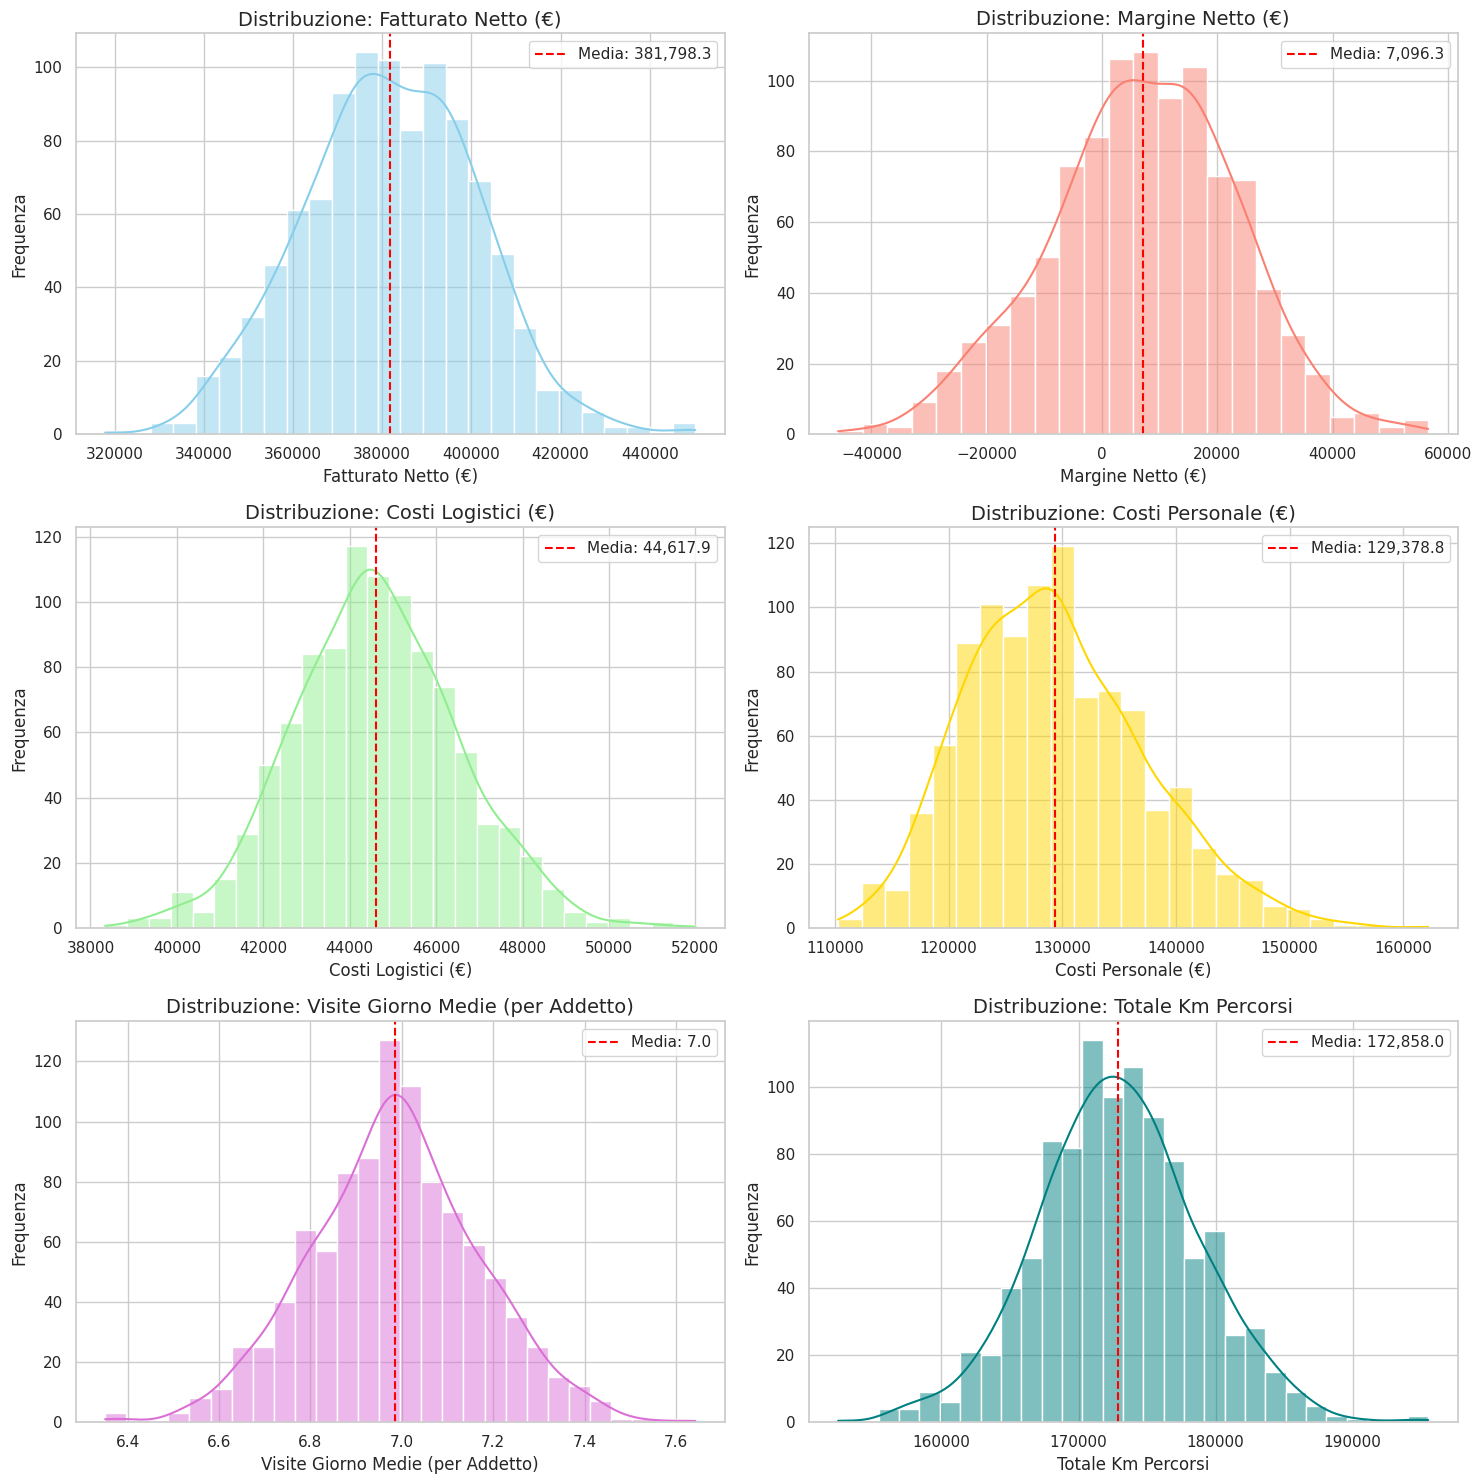

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid")

area_sim_df['visite_giorno_medie'] = area_sim_df['visite_giorno_per_addetto']

vars_to_plot = [
    ('ricavi_netti', 'Fatturato Netto (€)', 'skyblue'),
    ('margine_netto_operativo', 'Margine Netto (€)', 'salmon'),
    ('costo_logistica', 'Costi Logistici (€)', 'lightgreen'),
    ('costo_personale', 'Costi Personale (€)', 'gold'),
    ('visite_giorno_medie', 'Visite Giorno Medie (per Addetto)', 'orchid'),
    ('km_totali', 'Totale Km Percorsi', 'teal')
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, title, color) in enumerate(vars_to_plot):
    if col in area_sim_df.columns:
        sns.histplot(area_sim_df[col], kde=True, ax=axes[i], color=color)
        axes[i].set_title(f'Distribuzione: {title}', fontsize=14)
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frequenza')

        mean_val = area_sim_df[col].mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:,.1f}')
        axes[i].legend()

plt.tight_layout()
plt.show()


Visualizzazione: 01_distribuzione_margine.png


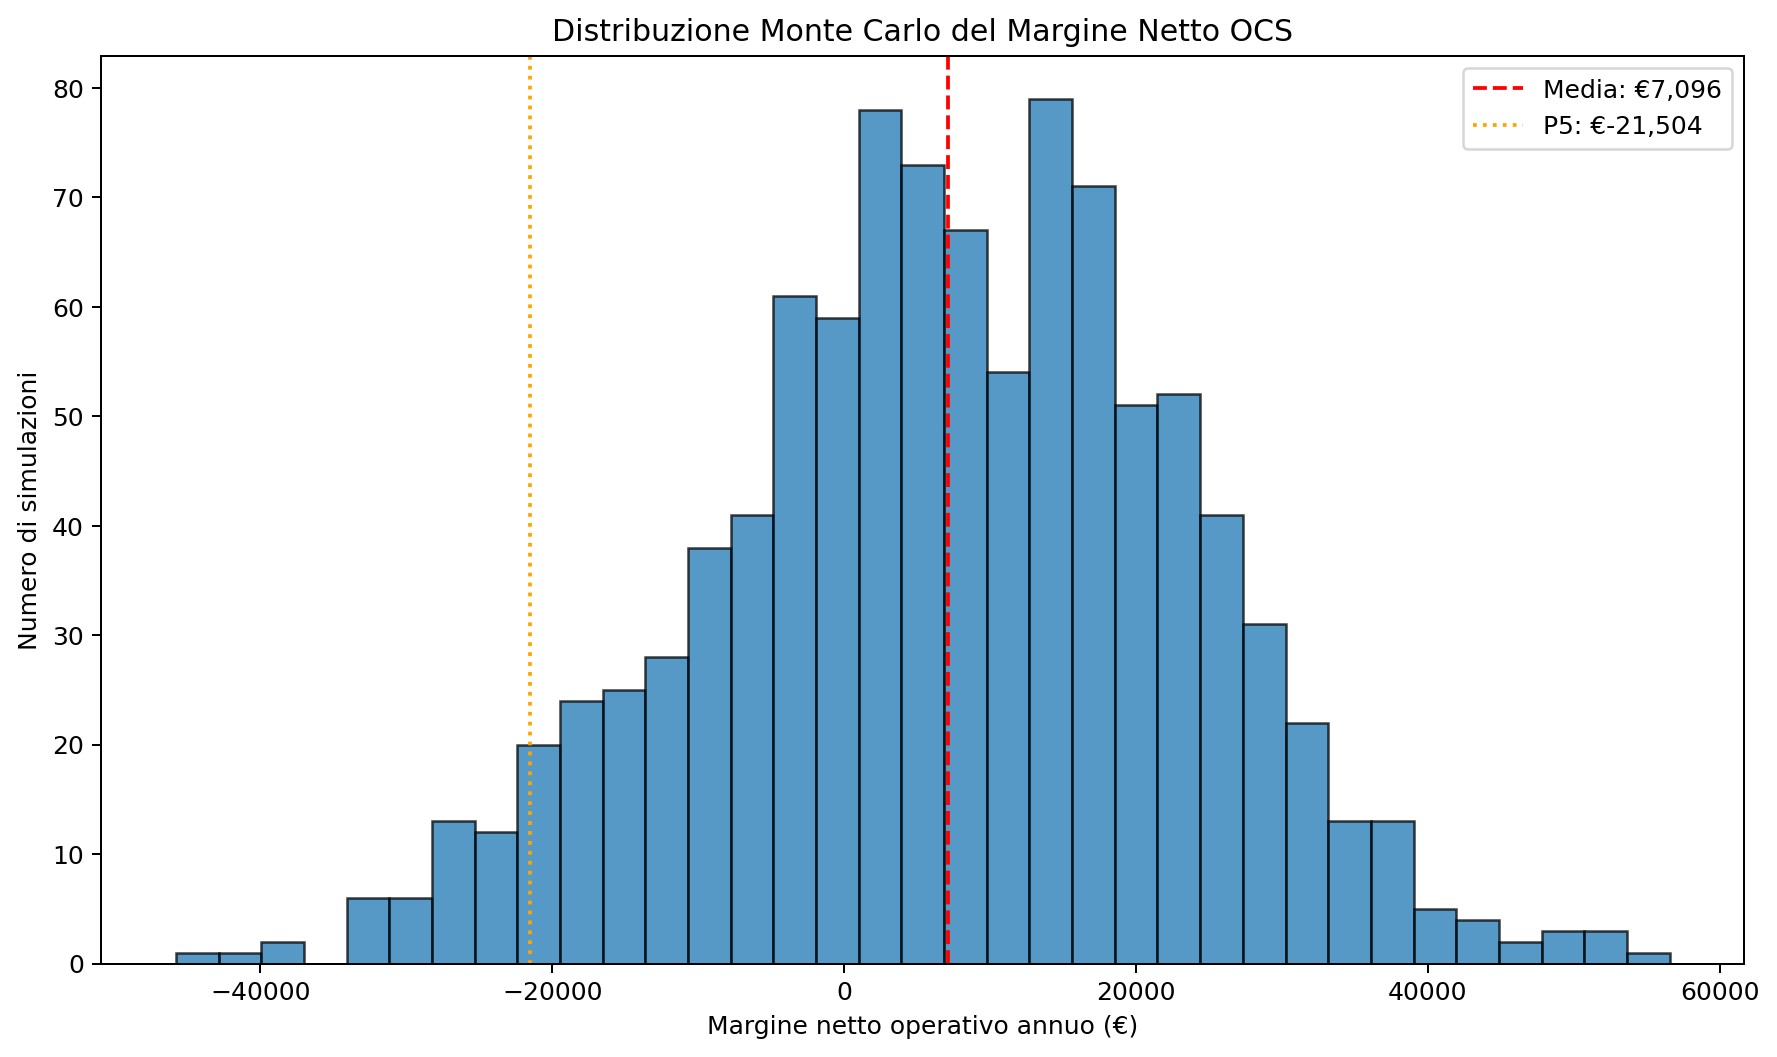

Visualizzazione: 02_distribuzione_roi.png


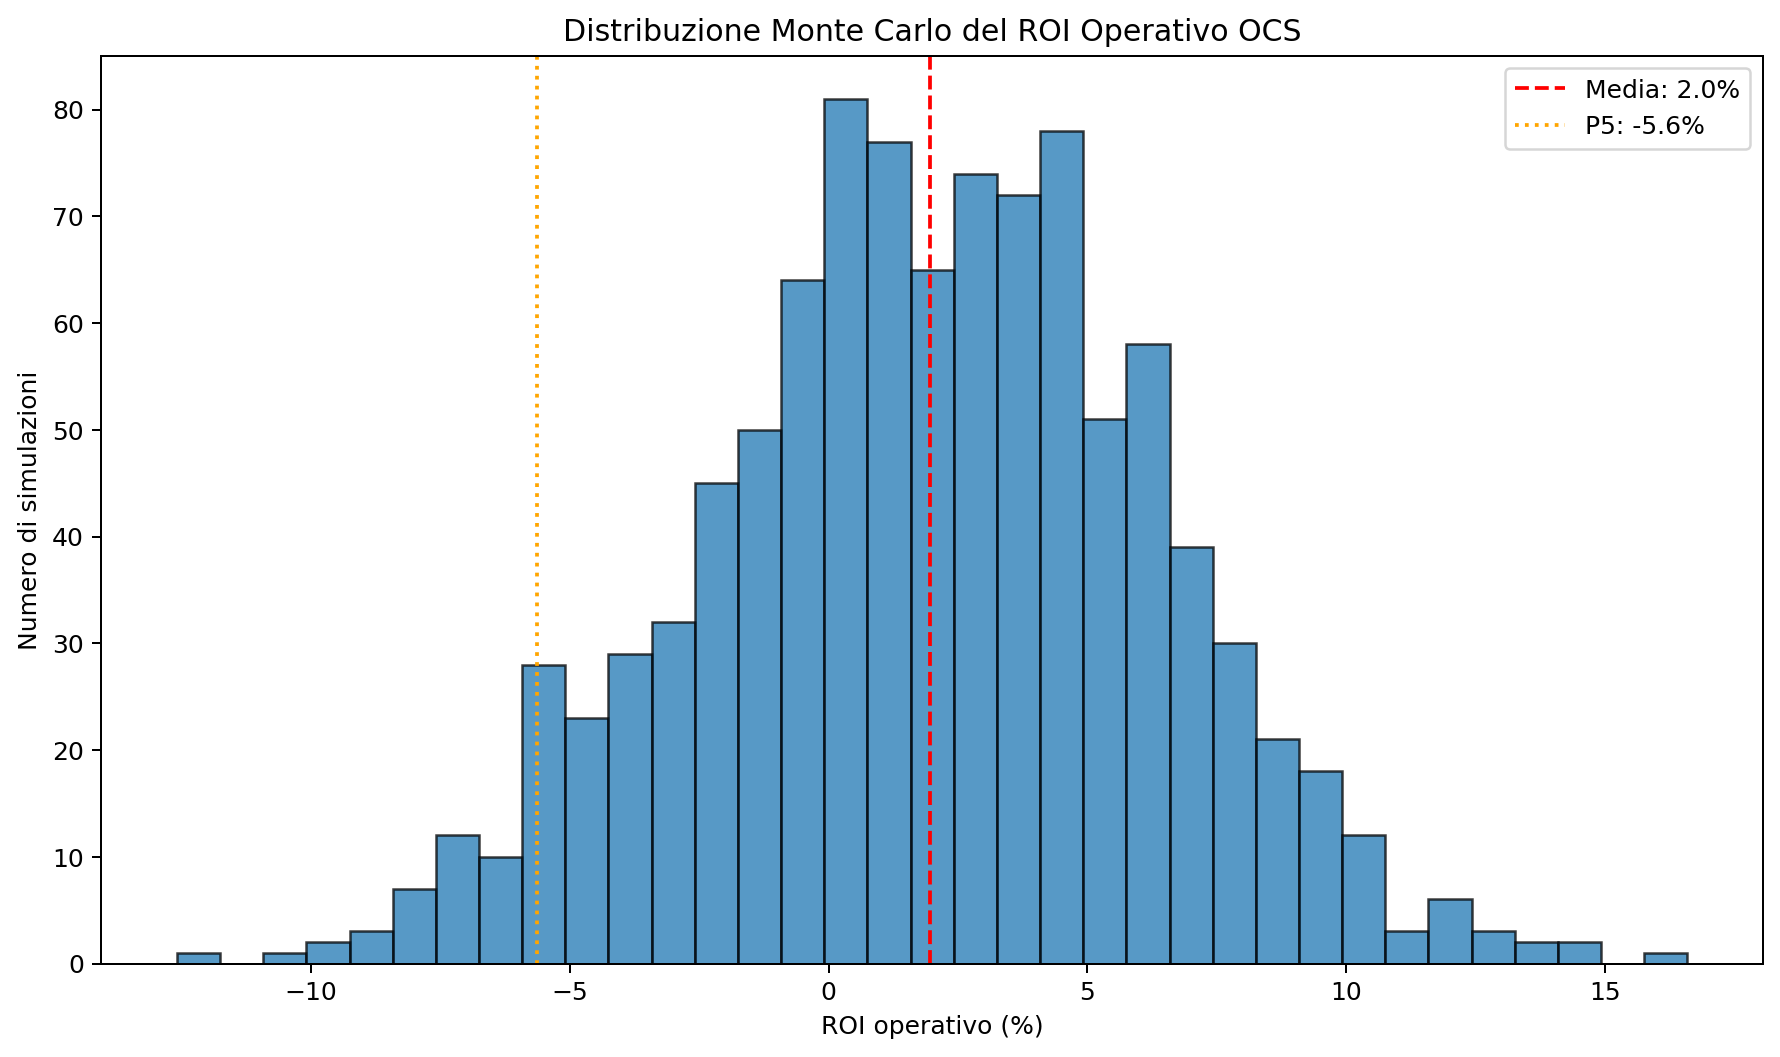

Visualizzazione: 03_impatto_km_margine.png


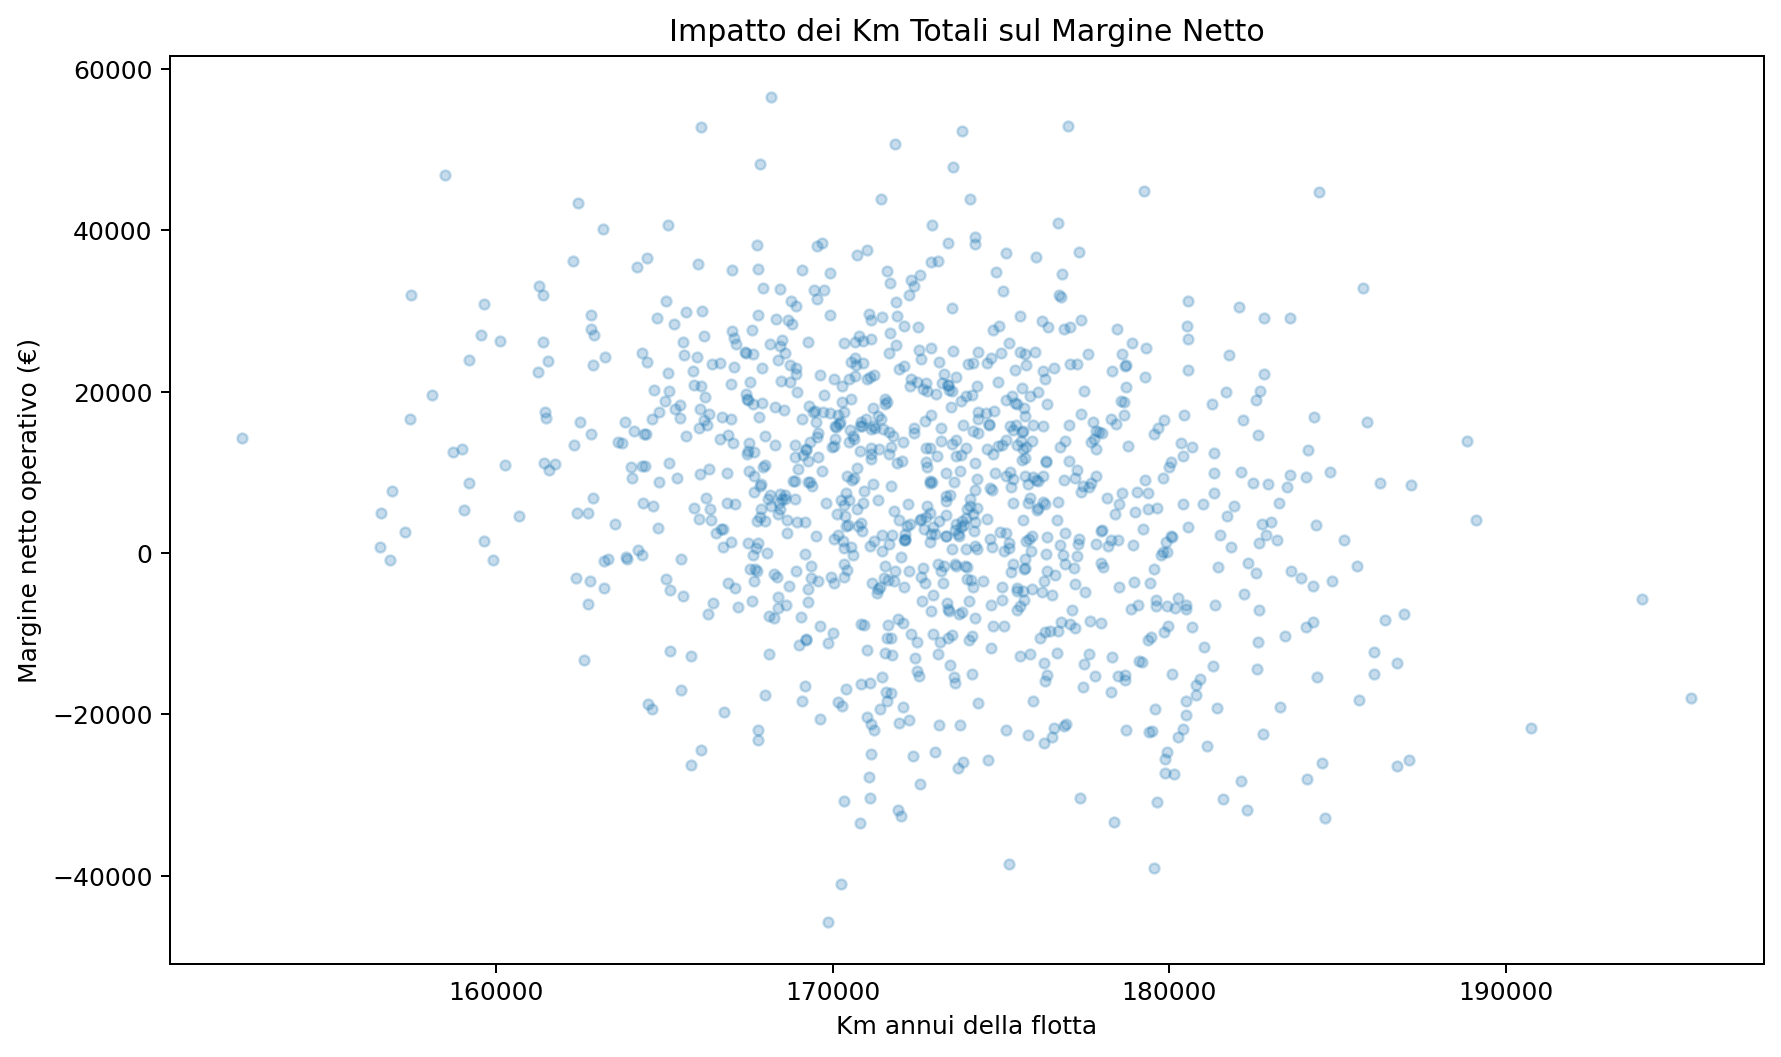

Visualizzazione: 04_sensibilita_margine.png


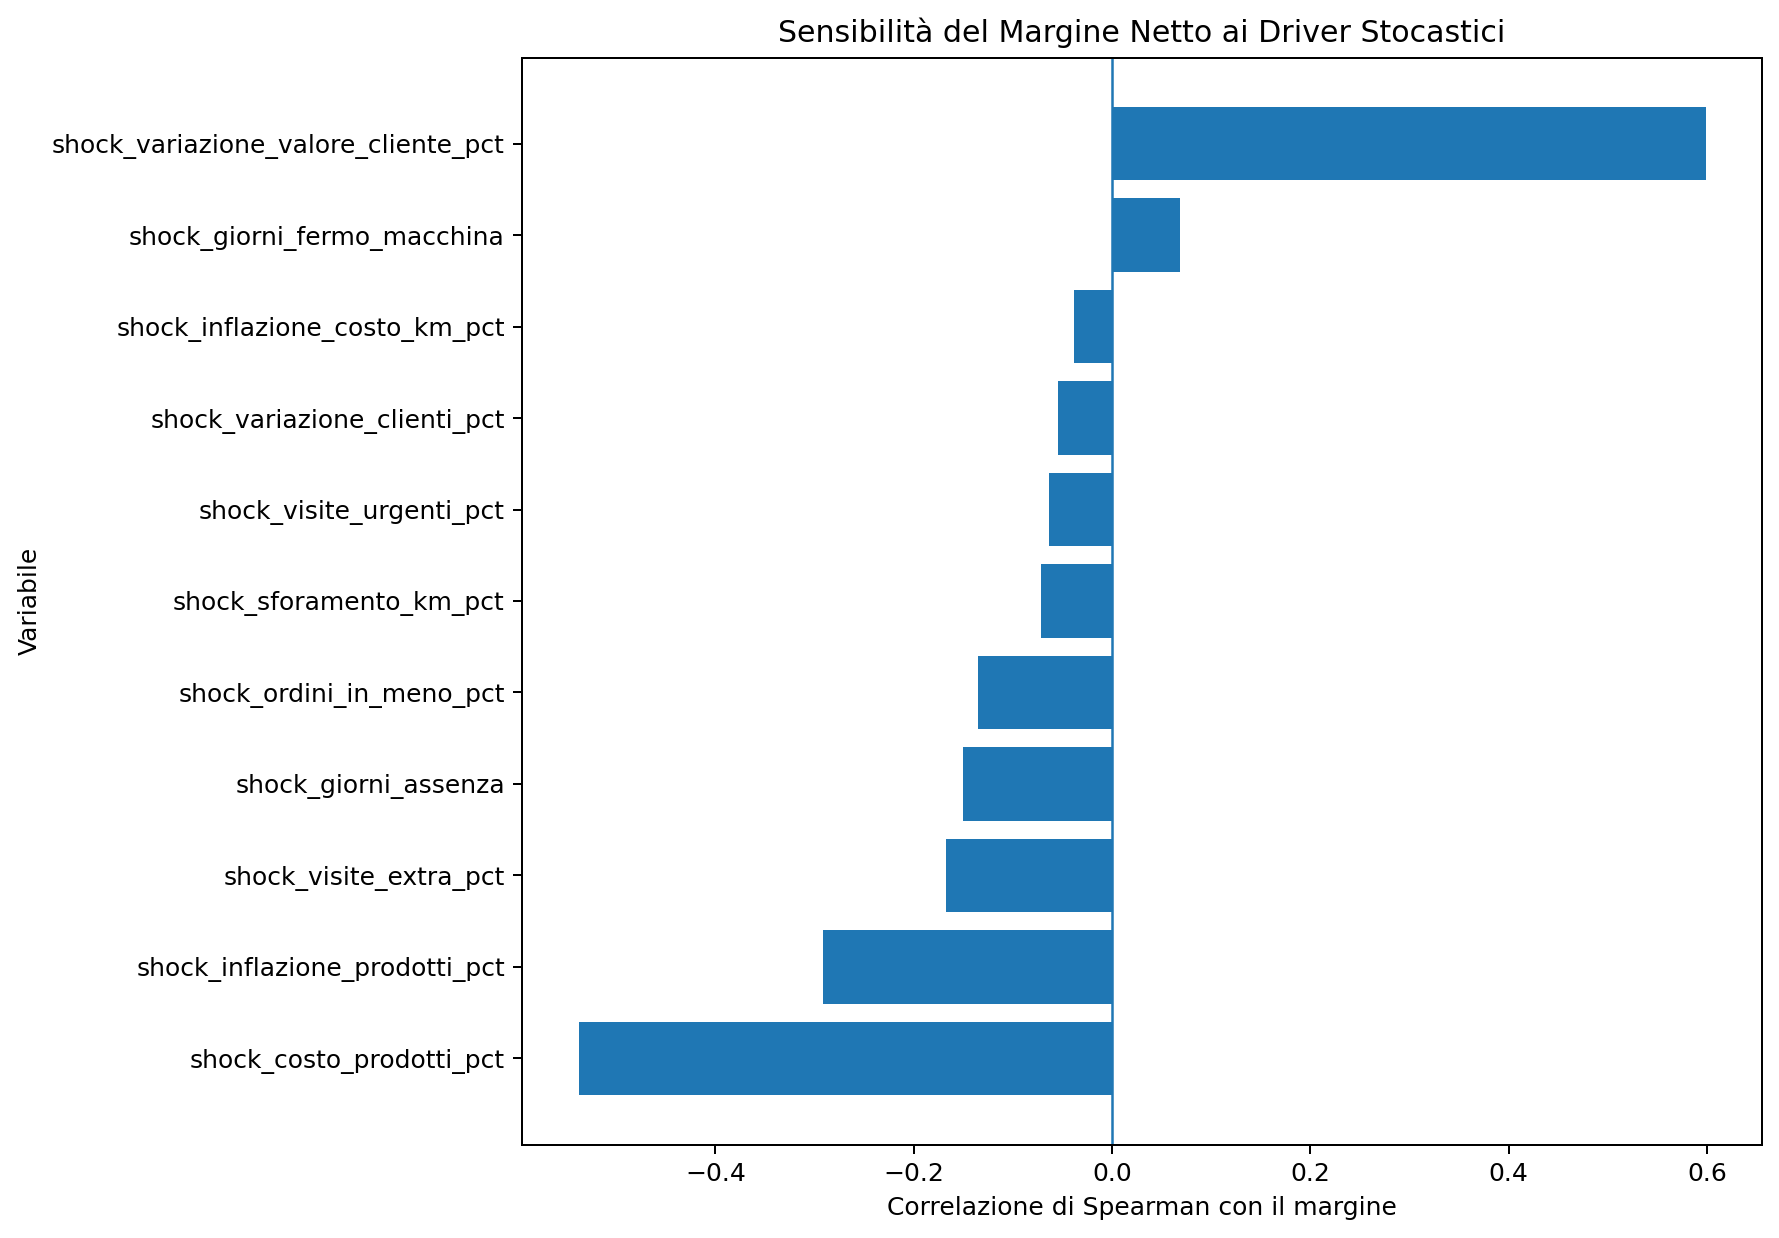

Visualizzazione: 05_confronto_addetti.png


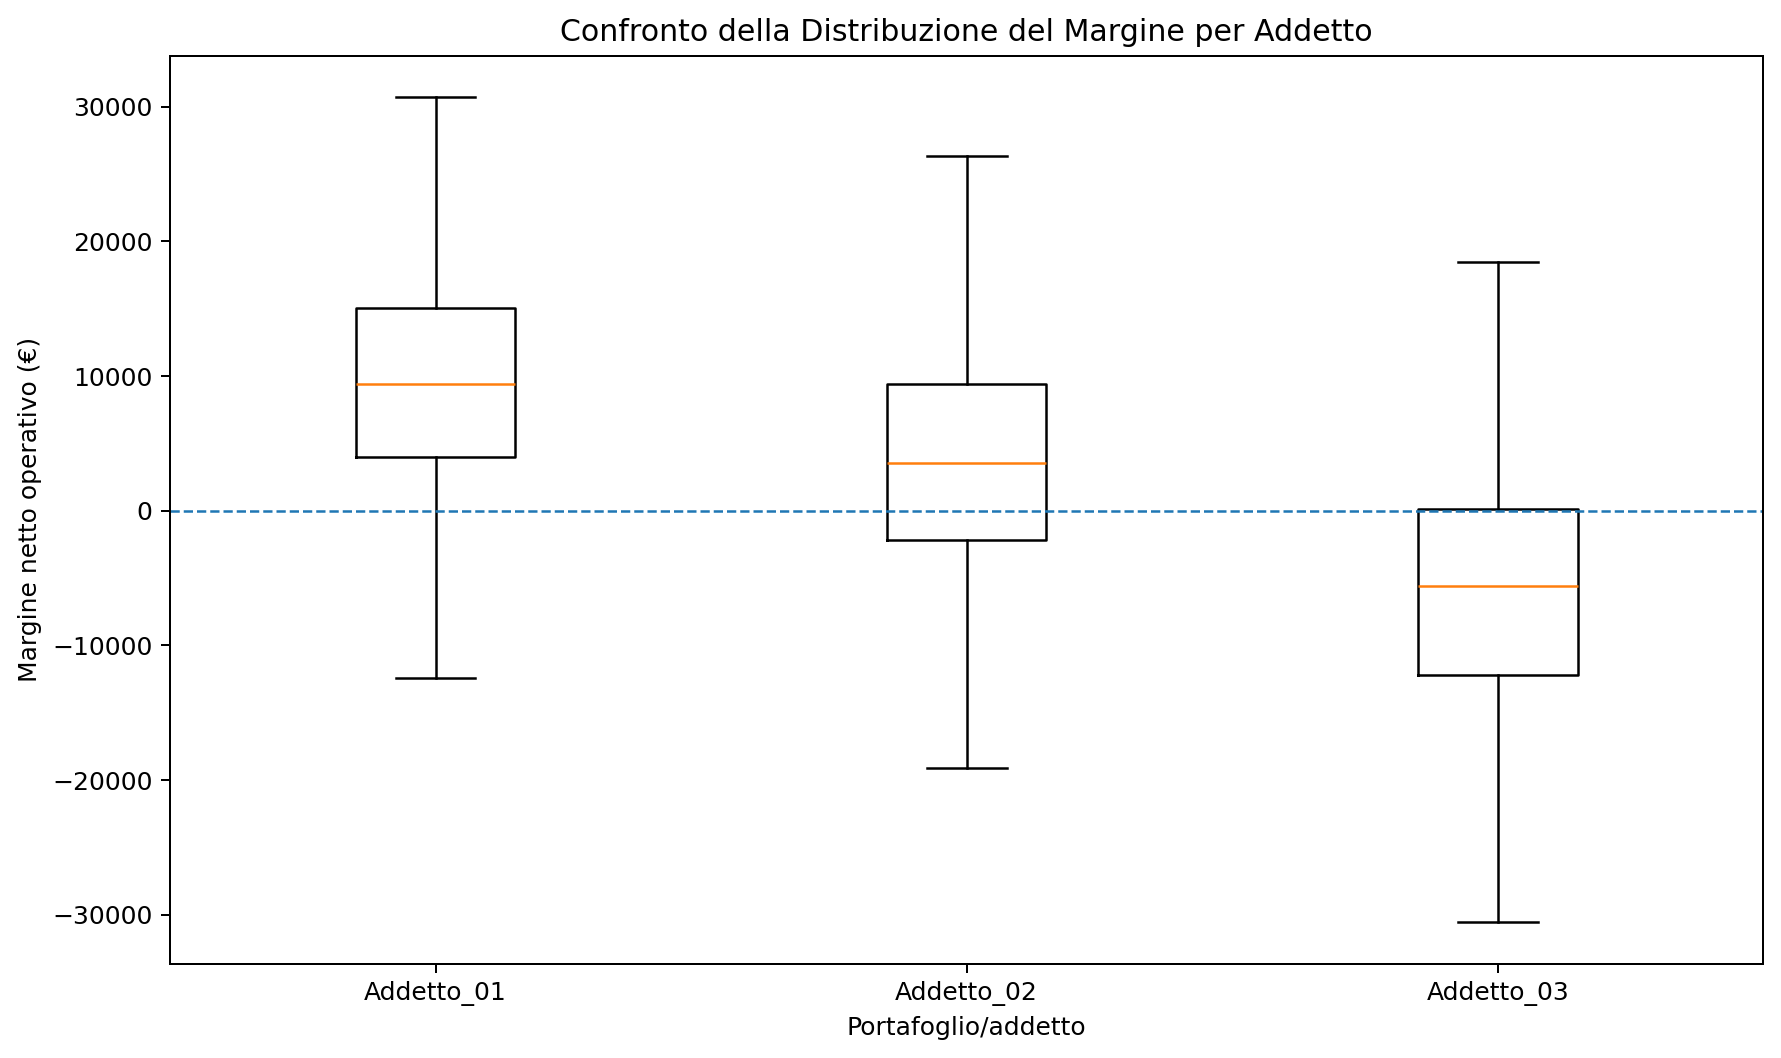

In [ ]:
import os
from IPython.display import Image, display

output_path = '/mnt/data/output_monte_carlo_ocs/'
if os.path.exists(output_path):
    files = [f for f in os.listdir(output_path) if f.endswith('.png')]
    if not files:
        print(f'Nessun file PNG trovato in {output_path}. Prova a controllare il percorso fisico nel browser dei file.')
    else:
        for file in sorted(files):
            print(f'Visualizzazione: {file}')
            display(Image(filename=os.path.join(output_path, file)))
else:
    print(f'La cartella {output_path} non esiste.')

[OK] Caricamento dati da: /mnt/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx


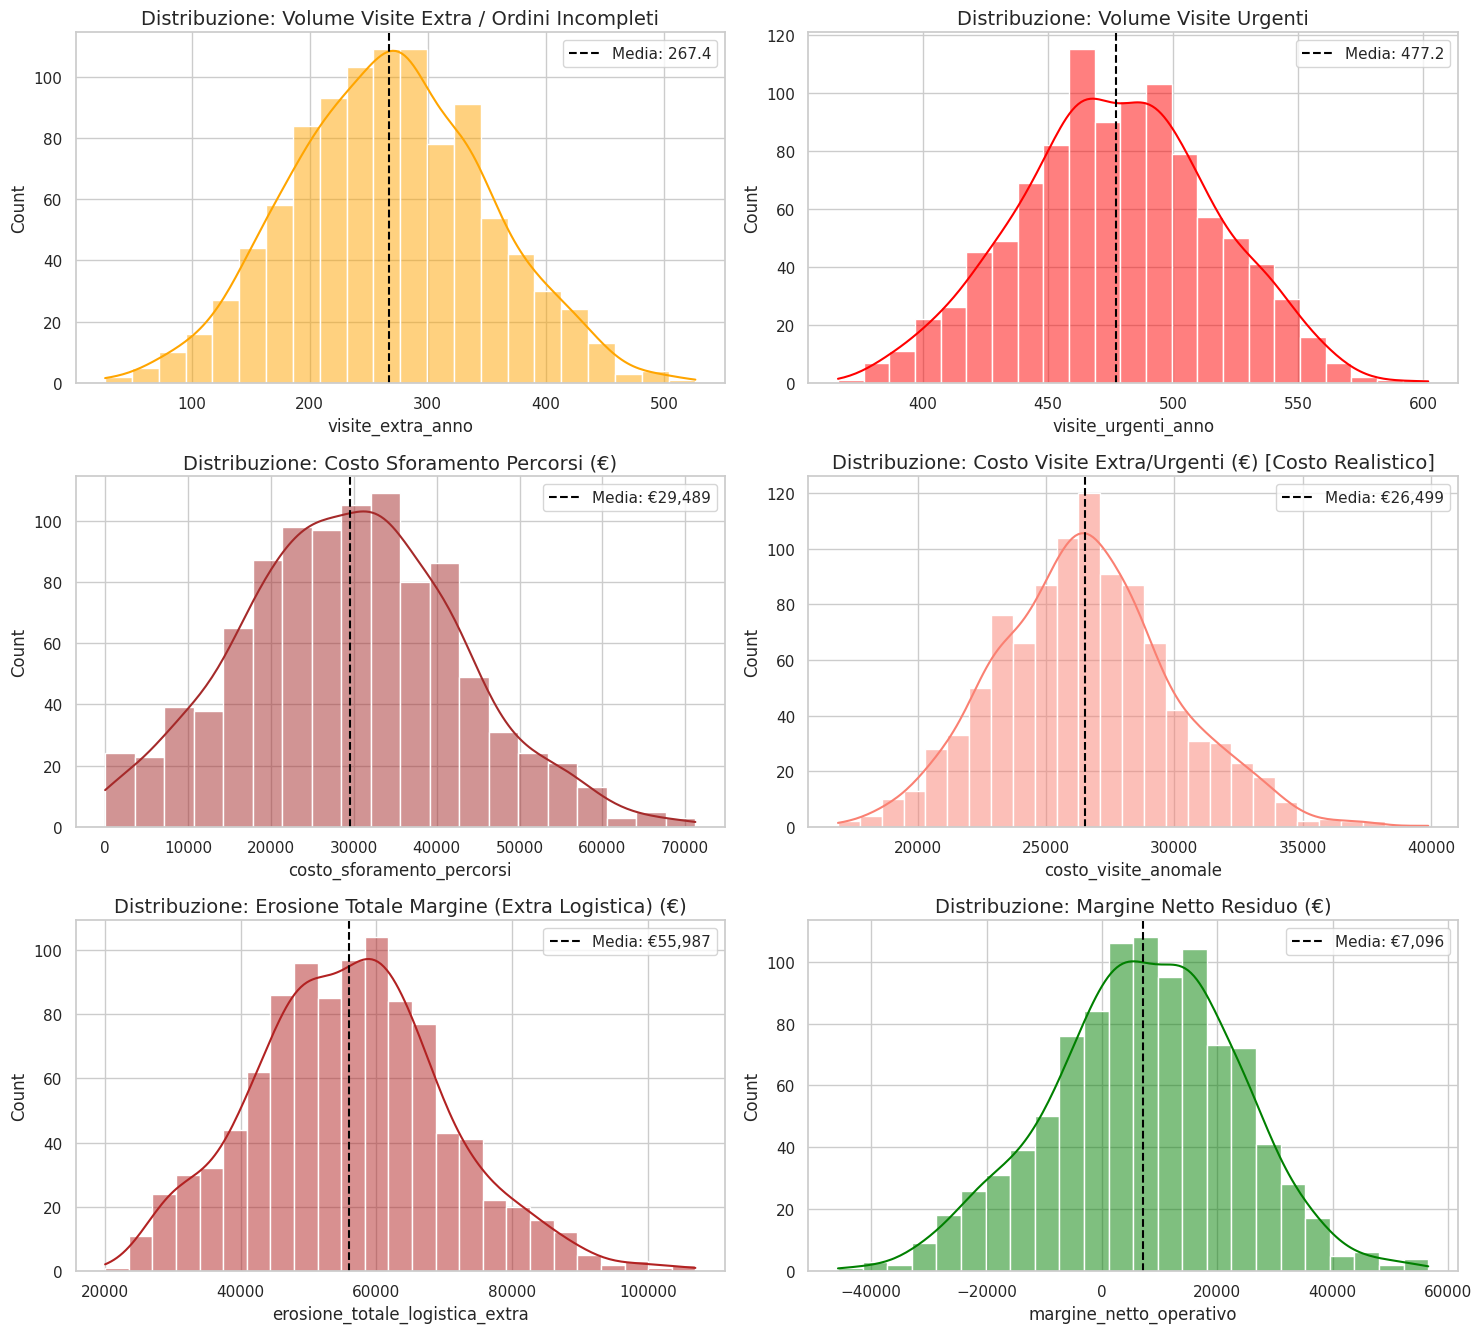

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def visualizza_erosione_margini_logistica(area_df):
    """
    Visualizza la distribuzione dell'erosione dei margini operativi causata dai costi
    logistici non programmati (sforamento percorsi, visite extra e urgenti).

    Utilizza il costo medio reale per visita (€20 - €30 / visita) comprensivo di
    lavoro del personale, flotta logistica, manutenzione macchine e interventi di guasto.
    """
    sns.set_theme(style="whitegrid")

    # --- CALCOLO DINAMICO DEL COSTO SERVIZIO E LOGISTICA PER VISITA SE NON PRESENTE ---
    if 'costo_per_visita' not in area_df.columns or area_df['costo_per_visita'].mean() > 50:
        if 'costo_personale' in area_df.columns and 'costo_logistica' in area_df.columns:
            costo_servizio = area_df['costo_personale'] + area_df['costo_logistica'] + area_df.get('costo_manutenzione_preventiva', 0) + area_df.get('costo_guasti', 0)
            area_df['costo_per_visita'] = costo_servizio / np.maximum(area_df['visite_totali_anno'], 1)
        else:
            area_df['costo_per_visita'] = 30.80

    costo_visita_reale = area_df['costo_per_visita']

    # 1. Costo reale delle visite anomale (Extra + Urgenti) basato sul costo medio reale per visita (€25 - €30)
    area_df['costo_visite_anomale'] = (area_df['visite_extra_anno'] + area_df['visite_urgenti_anno']) * costo_visita_reale

    # 2. Costo reale dello sforamento dei percorsi (deviazione itinerari + tempo guida extra del personale)
    costo_km_medio = area_df['costo_logistica'] / np.maximum(area_df['km_totali'], 1) if 'costo_logistica' in area_df.columns else 0.25
    sforamento_pct = area_df['shock_sforamento_km_pct'].clip(lower=0) if 'shock_sforamento_km_pct' in area_df.columns else 0.045
    km_extra_visite = (area_df['visite_extra_anno'] + area_df['visite_urgenti_anno']) * 18.0 if 'visite_extra_anno' in area_df.columns else 0
    km_ordinari = np.maximum(area_df['km_totali'] - km_extra_visite, 0)
    km_sforamento = km_ordinari * (sforamento_pct / (1 + sforamento_pct))
    costo_ora_guida = area_df['costo_personale'] / (264 * 8) if 'costo_personale' in area_df.columns else 20.0
    area_df['costo_sforamento_percorsi'] = (km_sforamento * costo_km_medio) + ((km_sforamento / 15.0) * costo_ora_guida)

    # 3. Erosione Totale Margini da Logistica Extra
    area_df['erosione_totale_logistica_extra'] = area_df['costo_visite_anomale'] + area_df['costo_sforamento_percorsi']

    vars_to_plot = [
        ('visite_extra_anno', 'Volume Visite Extra / Ordini Incompleti', 'orange'),
        ('visite_urgenti_anno', 'Volume Visite Urgenti', 'red'),
        ('costo_sforamento_percorsi', 'Costo Sforamento Percorsi (€)', 'brown'),
        ('costo_visite_anomale', 'Costo Visite Extra/Urgenti (€) [Costo Realistico]', 'salmon'),
        ('erosione_totale_logistica_extra', 'Erosione Totale Margine (Extra Logistica) (€)', 'firebrick'),
        ('margine_netto_operativo', 'Margine Netto Residuo (€)', 'green')
    ]

    n_vars = len(vars_to_plot)
    rows = (n_vars + 1) // 2
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(15, rows * 4.5))
    axes = axes.flatten()

    for i, (col, title, color) in enumerate(vars_to_plot):
        if col in area_df.columns:
            sns.histplot(area_df[col], kde=True, ax=axes[i], color=color)
            axes[i].set_title(f'Distribuzione: {title}', fontsize=14)
            mean_val = area_df[col].mean()
            label_text = f'Media: €{mean_val:,.0f}' if '€' in title else f'Media: {mean_val:,.1f}'
            axes[i].axvline(mean_val, color='black', linestyle='--', label=label_text)
            axes[i].legend()
        else:
            axes[i].text(0.5, 0.5, f'Variabile {col}\nnon disponibile', ha='center', va='center')

    if len(axes) > n_vars:
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()


# --- ESECUZIONE E CARICAMENTO DATI ---
percorsi_possibili = [
    Path('/mnt/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
    Path('./data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
    Path('C:/Users/user/Documents/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
]

path_excel = None
for p in percorsi_possibili:
    if p.exists():
        path_excel = p
        break

if path_excel:
    print(f"[OK] Caricamento dati da: {path_excel.resolve()}")
    area_sim_df = pd.read_excel(path_excel, sheet_name='Simulazioni_area')
    visualizza_erosione_margini_logistica(area_sim_df)
else:
    print("[AVVISO] File Excel non trovato. Assicurati di aver prima eseguito la simulazione Monte Carlo nel Primo Blocco.")

[OK] Caricamento dati per Blocco 3 da: /mnt/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx


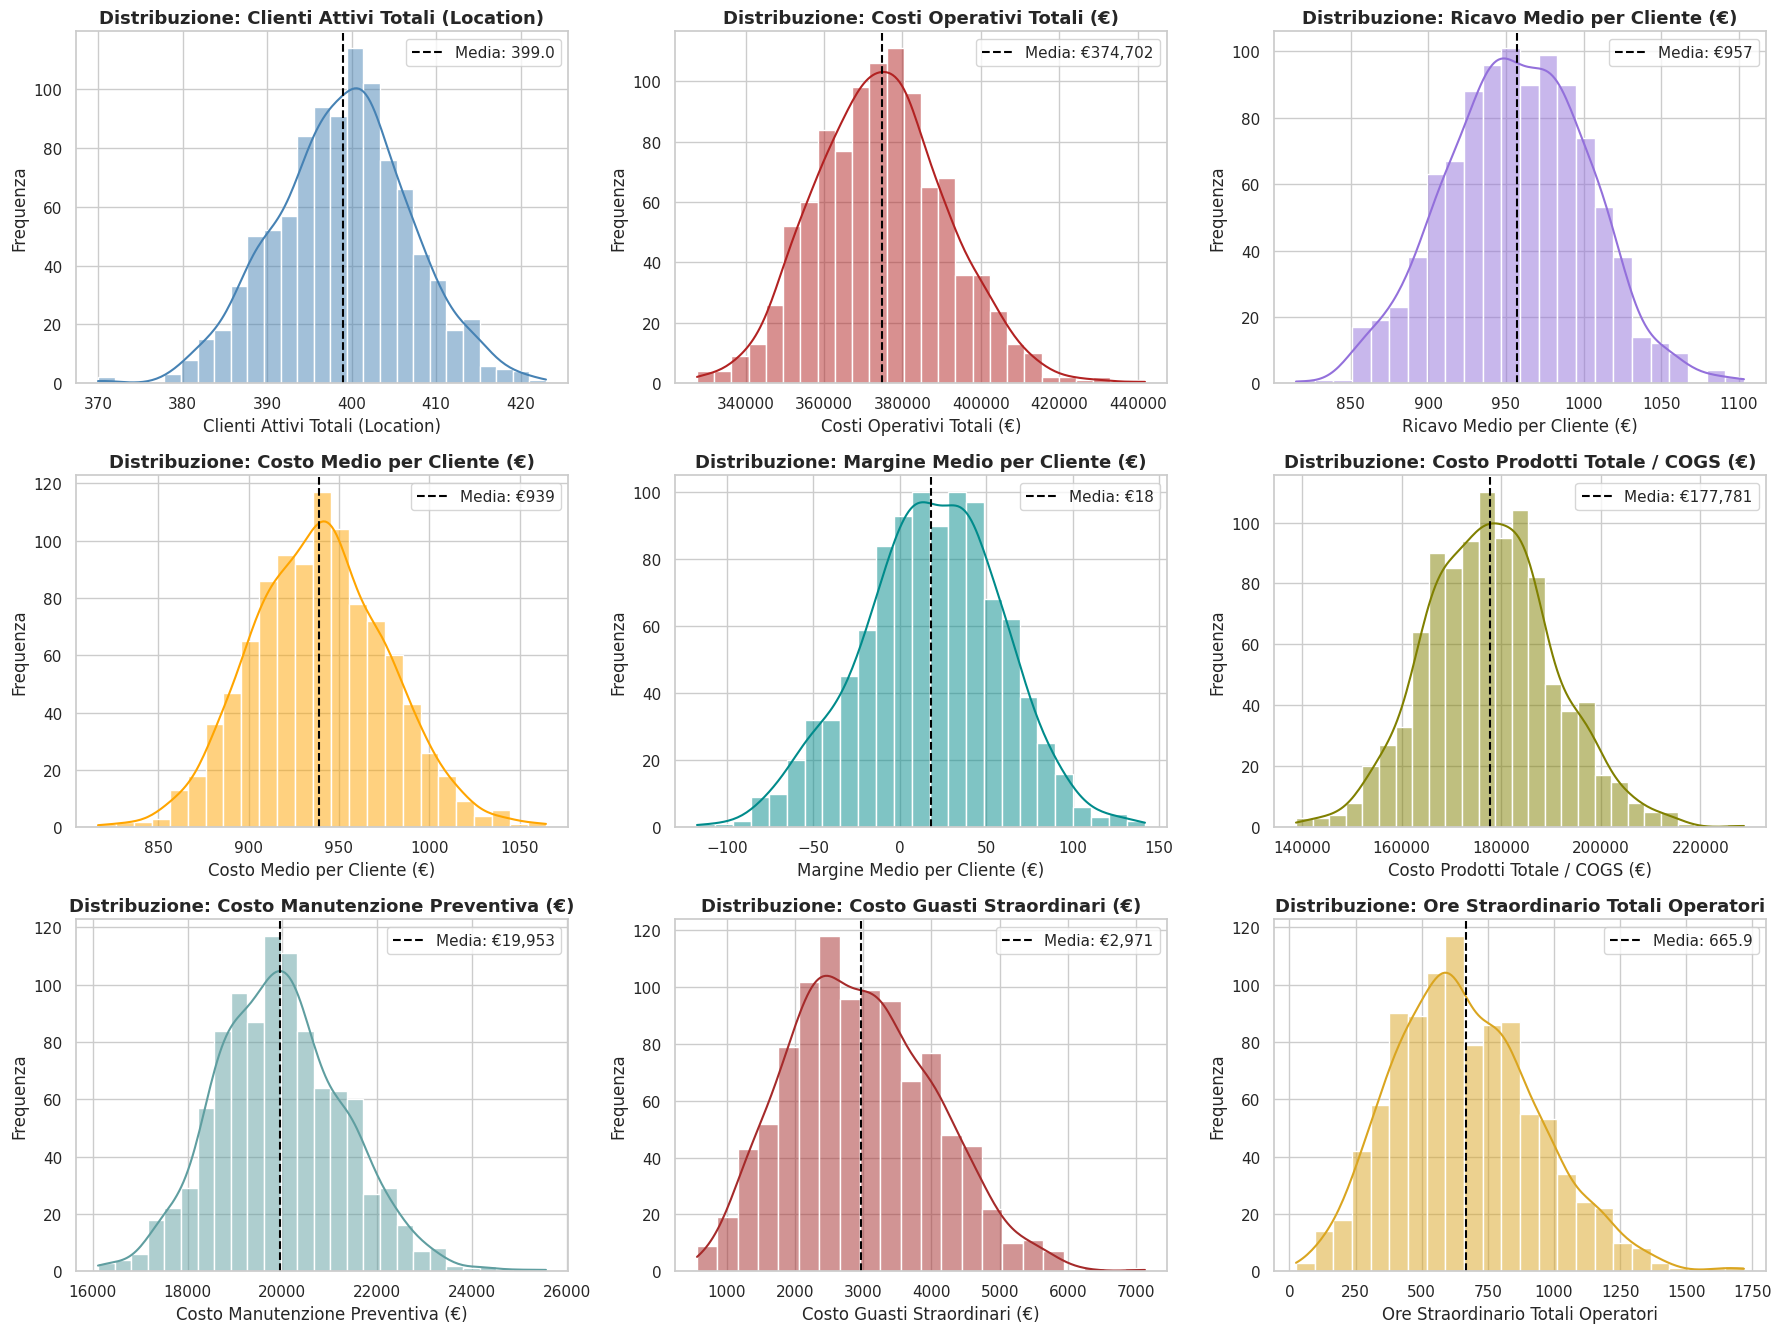

In [ ]:
# ==============================================================================
# BLOCCO 3: ANALISI AGGIUNTIVA VENDING & OCS
# ==============================================================================
# Visualizzazione avanzata dei KPI gestionali dei Distributori Automatici / OCS:
# - Redditività unitaria per cliente (Ricavo, Costo e Margine per Location)
# - Dettaglio dei costi operativi di gestione (Prodotti/COGS, Manutenzione, Guasti)
# - Impatto del carico di lavoro del personale (Ore Straordinario Operatori)
# ==============================================================================

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def visualizza_analisi_vending_ocs(area_df):
    """
    BLOCCO 3: Analisi Aggiuntiva Avanzata per Distributori Automatici / OCS.

    Visualizza la distribuzione delle metriche gestionali e operative chiave.
    Utilizza esclusivamente i dati reali generati dalla simulazione Monte Carlo nel Primo Blocco,
    calcolando le metriche unitarie se caricate da file esterno.
    """
    sns.set_theme(style="whitegrid")

    # --- CALCOLO DINAMICO DELLE METRICHE UNITARIE (SE DA FILE ESTERNO) ---
    if 'clienti_attivi' not in area_df.columns:
        if 'numero_addetti' in area_df.columns and 'clienti_per_addetto' in area_df.columns:
            area_df['clienti_attivi'] = area_df['numero_addetti'] * area_df['clienti_per_addetto']
        else:
            area_df['clienti_attivi'] = 420

    if 'ricavo_per_cliente' not in area_df.columns and 'ricavi_netti' in area_df.columns:
        area_df['ricavo_per_cliente'] = area_df['ricavi_netti'] / np.maximum(area_df['clienti_attivi'], 1)

    if 'costo_per_cliente' not in area_df.columns and 'costi_operativi_totali' in area_df.columns:
        area_df['costo_per_cliente'] = area_df['costi_operativi_totali'] / np.maximum(area_df['clienti_attivi'], 1)

    if 'margine_per_cliente' not in area_df.columns and 'margine_netto_operativo' in area_df.columns:
        area_df['margine_per_cliente'] = area_df['margine_netto_operativo'] / np.maximum(area_df['clienti_attivi'], 1)

    # Variabili operative Vending & OCS da plottare (senza ROI già presente nel Blocco 1/2)
    vars_to_plot = [
        ('clienti_attivi', 'Clienti Attivi Totali (Location)', 'steelblue'),
        ('costi_operativi_totali', 'Costi Operativi Totali (€)', 'firebrick'),
        ('ricavo_per_cliente', 'Ricavo Medio per Cliente (€)', 'mediumpurple'),
        ('costo_per_cliente', 'Costo Medio per Cliente (€)', 'orange'),
        ('margine_per_cliente', 'Margine Medio per Cliente (€)', 'darkcyan'),
        ('costo_prodotti', 'Costo Prodotti Totale / COGS (€)', 'olive'),
        ('costo_manutenzione_preventiva', 'Costo Manutenzione Preventiva (€)', 'cadetblue'),
        ('costo_guasti', 'Costo Guasti Straordinari (€)', 'brown'),
        ('ore_straordinario', 'Ore Straordinario Totali Operatori', 'goldenrod')
    ]

    n_vars = len(vars_to_plot)
    rows = (n_vars + 2) // 3
    fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, rows * 4.5))
    axes = axes.flatten()

    for i, (col, title, color) in enumerate(vars_to_plot):
        if col in area_df.columns:
            sns.histplot(area_df[col], kde=True, ax=axes[i], color=color)
            axes[i].set_title(f'Distribuzione: {title}', fontsize=13, fontweight='bold')
            axes[i].set_xlabel(title)
            axes[i].set_ylabel('Frequenza')

            mean_val = area_df[col].mean()
            label_text = f'Media: €{mean_val:,.0f}' if '€' in title else f'Media: {mean_val:,.1f}'
            axes[i].axvline(mean_val, color='black', linestyle='--', label=label_text)
            axes[i].legend(loc='upper right')
        else:
            axes[i].text(0.5, 0.5, f'Variabile {col}\nnon disponibile', ha='center', va='center')

    if len(axes) > n_vars:
        for idx in range(n_vars, len(axes)):
            fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()


# --- CARICAMENTO ED ESECUZIONE ---
percorsi_possibili = [
    Path('/mnt/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
    Path('./data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
    Path('C:/Users/user/Documents/data/output_monte_carlo_ocs/risultati_monte_carlo_ocs.xlsx'),
]

path_excel = None
for p in percorsi_possibili:
    if p.exists():
        path_excel = p
        break

if path_excel:
    print(f"[OK] Caricamento dati per Blocco 3 da: {path_excel.resolve()}")
    area_sim_df = pd.read_excel(path_excel, sheet_name='Simulazioni_area')
    visualizza_analisi_vending_ocs(area_sim_df)
else:
    print("[AVVISO] File Excel non trovato. Assicurati di aver prima eseguito la simulazione Monte Carlo nel Primo Blocco.")


### 🔄 Modifica Dinamica dei Parametri e Ricalcolo
È possibile aggiornare i parametri (nei portafogli o negli shock) e richiamare direttamente `simula_regione(PORTAFOGLI_ADDETTI)` per aggiornare istantaneamente l'intera simulazione e i grafici.


In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

# Esempio: Aggiornamento dinamico di un parametro e ricalcolo immediato
NUOVO_VALORE_CLIENTE = 1100

for p in PORTAFOGLI_ADDETTI:
    p['valore_annuo_cliente_base'] = NUOVO_VALORE_CLIENTE

# Rieseguiamo la simulazione direttamente usufruendo delle formule del primo blocco
detail_sim_df, area_sim_df = simula_regione(PORTAFOGLI_ADDETTI)

print(f"✅ Ricalcolo completato con valore cliente base = €{NUOVO_VALORE_CLIENTE}:")
display(area_sim_df[['ricavi_netti', 'costi_operativi_totali', 'margine_netto_operativo', 'roi_operativo_pct']].describe(percentiles=[0.05, 0.5, 0.95]).round(0).astype(int))


✅ Ricalcolo completato con valore cliente base = €1100:


,ricavi_netti,costi_operativi_totali,margine_netto_operativo,roi_operativo_pct
count,1000,1000,1000,1000
mean,419978,392480,27498,7
std,21294,17831,17429,5
min,349604,342283,-30686,-8
5%,384391,364944,-3198,-1
50%,420235,391932,27951,7
95%,453340,422608,54615,14
max,495261,464689,79807,22


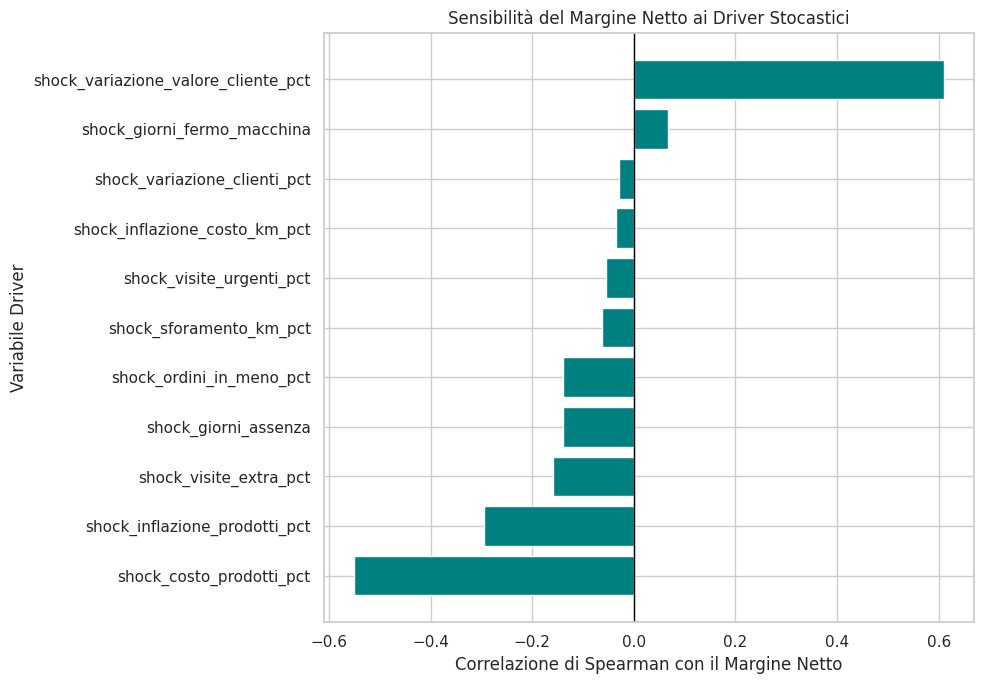

In [ ]:
# Sensibilità del Margine Netto rispetto ai Driver Stocastici
sens_df = sensitivity(area_sim_df)

d = sens_df.sort_values("correlazione_spearman")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(d["variabile"], d["correlazione_spearman"], color='teal')
ax.axvline(0, color='black', linewidth=1)
ax.set(title="Sensibilità del Margine Netto ai Driver Stocastici",
       xlabel="Correlazione di Spearman con il Margine Netto",
       ylabel="Variabile Driver")
fig.tight_layout()
plt.show()


Sintesi per Addetto:


,addetto,clienti_media,valore_per_addetto_media,margine_medio,margine_P5,margine_P50,margine_P95,probabilita_perdita,roi_medio_pct,km_medi,visite_giorno_medie,costo_visita_medio,saturazione_media,probabilita_sovraccarico,costo_cliente_medio,margine_cliente_medio
0,Addetto_01,133.16,139907.91,16343.39,1792.78,16083.45,31175.22,0.03,13.27,49354.49,6.99,31.61,0.95,0.27,928.16,122.40
1,Addetto_02,132.95,140475.37,10309.71,-5273.13,10377.81,26614.08,0.14,8.12,57695.28,6.99,35.09,1.09,0.84,979.04,77.73
2,Addetto_03,132.85,139594.85,844.92,-16418.59,1133.48,17301.23,0.46,0.79,65808.25,6.97,40.11,1.21,1.00,1044.15,6.70


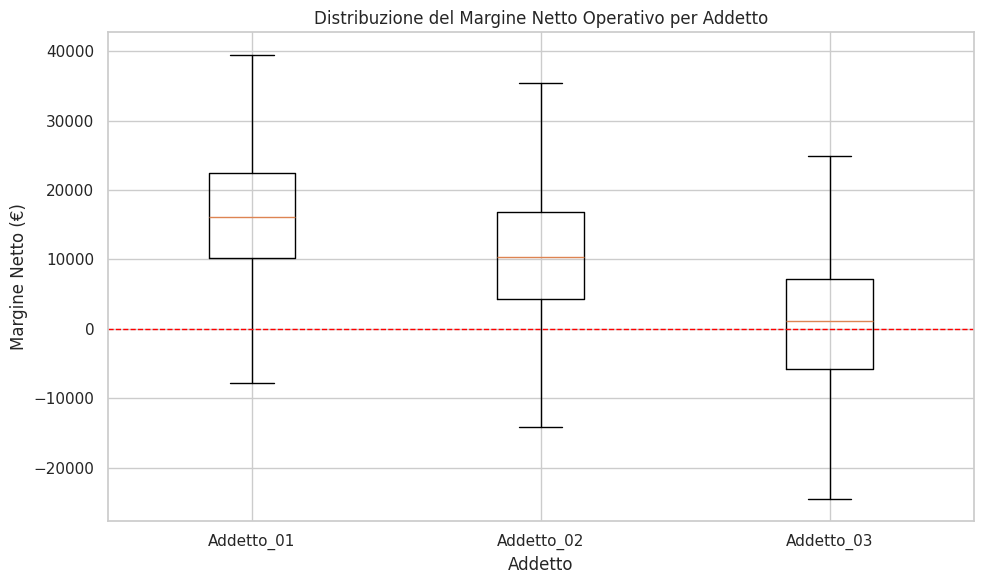

In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

# Sintesi e Confronto dei Portafogli Addetti
op_summary = addetti_summary(detail_sim_df)
print("Sintesi per Addetto:")
display(op_summary.round(2))

groups = [g["margine_netto_operativo"].to_numpy() for _, g in detail_sim_df.groupby("addetto")]
labels = [name for name, _ in detail_sim_df.groupby("addetto")]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.axhline(0, color='red', linestyle="--", linewidth=1)
ax.set(title="Distribuzione del Margine Netto Operativo per Addetto",
       xlabel="Addetto",
       ylabel="Margine Netto (€)")
fig.tight_layout()
plt.show()


### Analisi KM Medi Mensili per Cliente
In questa sezione calcoliamo l'efficienza logistica espressa in km percorsi mensilmente per ogni cliente servito, includendo la variabilità stocastica richiesta.

In [ ]:
import numpy as np
import pandas as pd

# 1. Calcolo Deterministico (basato sull'ultima simulazione)
# Usiamo include_groups=False per evitare il DeprecationWarning di Pandas
km_mensili_per_cliente_det = detail_sim_df.groupby('addetto').apply(lambda x:
    (x['km_totali'] / 12) / x['clienti_attivi'], include_groups=False
).groupby('addetto').mean()

print("--- Valori Deterministici (Media delle simulazioni) ---")
for addetto, valore in km_mensili_per_cliente_det.items():
    print(f"{addetto}: {valore:.2f} km/mese per cliente")

# 2. Calcolo Stocastico (Gaussiana con SD = 5 km)
rng = np.random.default_rng(SEED)

# Creazione DataFrame per l'analisi stocastica
analisi_km = detail_sim_df[['simulazione', 'addetto', 'km_totali', 'clienti_attivi']].copy()
analisi_km['km_mensili_cliente_base'] = (analisi_km['km_totali'] / 12) / analisi_km['clienti_attivi']

# Applicazione shock gaussiano
analisi_km['km_mensili_cliente_stocastico'] = analisi_km['km_mensili_cliente_base'] + \
                                             rng.normal(0, 5, len(analisi_km))

# Sintesi Risultati
sintesi_km = analisi_km.groupby('addetto')['km_mensili_cliente_stocastico'].agg([
    'mean', 'std', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)
]).rename(columns={'mean': 'Media Stocastica', 'std': 'Dev.Std', '<lambda_0>': 'P5', '<lambda_1>': 'P95'})

display(sintesi_km.round(2))

--- Valori Deterministici (Media delle simulazioni) ---
Addetto_01: 30.89 km/mese per cliente
Addetto_02: 36.16 km/mese per cliente
Addetto_03: 41.28 km/mese per cliente


,Media Stocastica,Dev.Std,P5,P95
addetto,,,,
Addetto_01,30.74,5.20,22.14,39.08
Addetto_02,35.75,5.30,26.99,44.77
Addetto_03,41.45,5.45,32.31,50.37


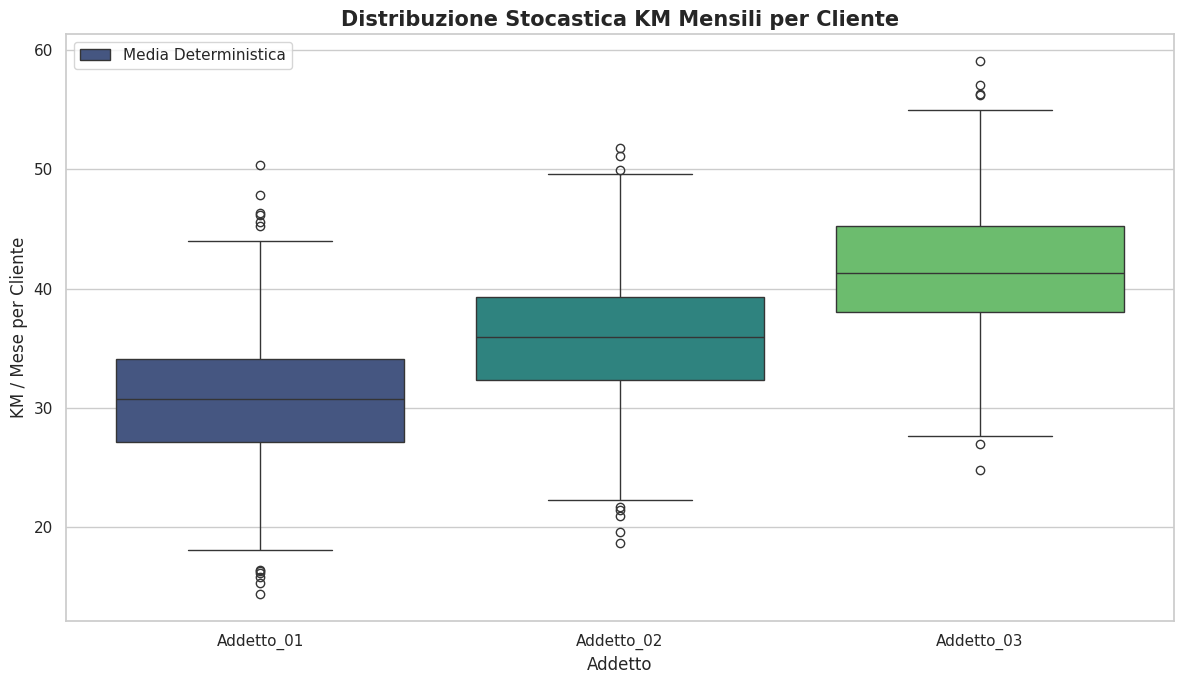

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Impostazione tema
sns.set_theme(style="whitegrid")

# Creazione del grafico
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=analisi_km,
    x='addetto',
    y='km_mensili_cliente_stocastico',
    palette='viridis',
    hue='addetto',
    legend=False
)

# Aggiunta delle medie deterministiche come punti di riferimento
for i, addetto in enumerate(km_mensili_per_cliente_det.index):
    plt.scatter(i, km_mensili_per_cliente_det[addetto], color='red', marker='D', s=100, label='Media Det.' if i == 0 else "")

plt.title('Distribuzione Stocastica KM Mensili per Cliente', fontsize=15, fontweight='bold')
plt.xlabel('Addetto', fontsize=12)
plt.ylabel('KM / Mese per Cliente', fontsize=12)
plt.legend(['Media Deterministica'], loc='upper left')

plt.tight_layout()
plt.show()